In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**FSC-147 dataset load, unzip and inspection**

In [19]:
# Setup all necessary path for FSC-147 dataset

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/MSc_Project_ZeroShot_Counting")
DATA_ROOT = PROJECT_ROOT / "datasets"

FSC147_ROOT = DATA_ROOT / "FSC147"
FSC147_RAW = FSC147_ROOT / "raw"

FSC147_IMAGE_DIR = FSC147_RAW / "images_384_VarV2"
FSC147_DENSITY_DIR = FSC147_RAW / "gt_density_map_adaptive_384_VarV2"

FSC147_ANNOTATION_FILE = FSC147_RAW / "annotation_FSC147_384.json"
FSC147_SPLIT_FILE = FSC147_RAW / "Train_Test_Val_FSC_147.json"
FSC147_CLASS_FILE = FSC147_RAW / "ImageClasses_FSC147.txt"

# Original ZIP location, if still present
FSC147_ZIP = FSC147_RAW / "FSC147_384_V2.zip"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_ROOT    :", DATA_ROOT)
print("FSC147_ROOT  :", FSC147_ROOT)
print("FSC147_RAW   :", FSC147_RAW)

PROJECT_ROOT : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting
DATA_ROOT    : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets
FSC147_ROOT  : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets/FSC147
FSC147_RAW   : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets/FSC147/raw


In [20]:
# Check if the FSC147_RAW (\FSC147\RAW) already exist

FSC147_RAW.mkdir(parents=True, exist_ok=True)

print("FSC-147 directory ready:", FSC147_RAW)

FSC-147 directory ready: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets/FSC147/raw


In [21]:
# Check whether FSC-147 Dataset is already prepared

required_fsc147_paths = {
    "Images directory": FSC147_IMAGE_DIR,
    "Density-map directory": FSC147_DENSITY_DIR,
    "Annotation JSON": FSC147_ANNOTATION_FILE,
    "Split JSON": FSC147_SPLIT_FILE,
    "Class mapping": FSC147_CLASS_FILE,
}

print("=== FSC-147 SETUP CHECK ===")

all_ready = True

for name, path in required_fsc147_paths.items():
    exists = path.exists()
    print(f"{name:25s}: {'OK' if exists else 'MISSING'}")
    all_ready &= exists

print()

if all_ready:
    print("FSC-147 is already prepared. No extraction is required.")
else:
    print("FSC-147 setup is incomplete.")

=== FSC-147 SETUP CHECK ===
Images directory         : OK
Density-map directory    : OK
Annotation JSON          : OK
Split JSON               : OK
Class mapping            : OK

FSC-147 is already prepared. No extraction is required.


In [22]:
# Extract ONLY IF the FSC-147 setup is incomplete

if not FSC147_IMAGE_DIR.exists() or not FSC147_DENSITY_DIR.exists():

    if FSC147_ZIP.exists():
        print("Extracting FSC-147...")

        !unzip -q "$FSC147_ZIP" -d "$FSC147_RAW"

        print("Extraction complete.")

    else:
        print(
            "FSC-147 extracted data is missing, but the ZIP file "
            f"was not found at:\n{FSC147_ZIP}"
        )

else:
    print("FSC-147 images and density maps already exist. Skipping extraction.")

FSC-147 images and density maps already exist. Skipping extraction.


**FSC-147 dataset inspection**

In [23]:
# check # of images and density maps

import os

image_dir = f"{FSC147_ROOT}/raw/images_384_VarV2"
density_dir = f"{FSC147_ROOT}/raw/gt_density_map_adaptive_384_VarV2"

print("Images:", len(os.listdir(image_dir)))
print("Density maps:", len(os.listdir(density_dir)))

Images: 6146
Density maps: 6146


In [24]:
# check *.json file

import json
from pathlib import Path

root = Path(FSC147_ROOT) / "raw"

with open(root / "annotation_FSC147_384.json") as f:
    annotations = json.load(f)

with open(root / "Train_Test_Val_FSC_147.json") as f:
    splits = json.load(f)

print("Annotation entries:", len(annotations))
print("Annotation example keys:", list(next(iter(annotations.values())).keys()))

print("\nSplit keys:", splits.keys())
for k, v in splits.items():
    print(k, len(v))

print("\nFirst few image IDs in train:")
print(splits["train"][:5])

Annotation entries: 6146
Annotation example keys: ['H', 'W', 'box_examples_coordinates', 'box_examples_path', 'density_path', 'density_path_fixed', 'img_path', 'points', 'r', 'ratio_h', 'ratio_w']

Split keys: dict_keys(['test', 'test_coco', 'train', 'val', 'val_coco'])
test 1190
test_coco 282
train 3659
val 1286
val_coco 277

First few image IDs in train:
['7.jpg', '9.jpg', '19.jpg', '20.jpg', '21.jpg']


Try 1 image to investigate annotation keys

In [25]:
# check a image (2.jpg) json information

image_id = "2.jpg"

ann = annotations[image_id]

print("Image:", image_id)

for key, value in ann.items():
    if isinstance(value, list):
        print(f"\n{key}:")
        print(f"  type: list")
        print(f"  length: {len(value)}")
        print(f"  first values: {value[:3]}")
    else:
        print(f"\n{key}: {value}")

Image: 2.jpg

H: 485

W: 800

box_examples_coordinates:
  type: list
  length: 3
  first values: [[[291, 234], [291, 312], [374, 312], [374, 234]], [[388, 228], [388, 311], [472, 311], [472, 228]], [[500, 228], [500, 312], [580, 312], [580, 228]]]

box_examples_path:
  type: list
  length: 1
  first values: ['/nfs/bigneuron/viresh/FSC_NewDataOnly/box_examples/2_0.jpg']

density_path: /nfs/bigneuron/viresh/FSC_NewDataOnly/gt_density_map_adaptive_384_VarV2/2.npy

density_path_fixed: /nfs/bigneuron/viresh/FSC_NewDataOnly/gt_density_map_fixed/2.npy

img_path: /nfs/bigneuron/viresh/FSC_NewDataOnly/images_384_VarV2/2.jpg

points:
  type: list
  length: 8
  first values: [[49.2078375, 243.82812371134017], [112.96676250000002, 240.5344329896907], [221.8032, 246.02919587628867]]

r:
  type: list
  length: 2
  first values: [50, 50]

ratio_h: 0.7917525773195876

ratio_w: 0.79125


In [26]:
print("\nGT count =", len(ann["points"]))


GT count = 8


Check image class information

In [27]:
image_id = "2.jpg"

with open(root / "ImageClasses_FSC147.txt") as f:
    image_to_class = {}

    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            image_to_class[parts[0]] = parts[1]

print("Image:", image_id)
print("Class:", image_to_class[image_id])

Image: 2.jpg
Class: sea shells


In [28]:
for split_name in ["train", "val", "test"]:
    if image_id in splits[split_name]:
        print("Split:", split_name)

Split: test


Check the distribution of number of exemplar boxes per image

In [29]:
from collections import Counter

n_boxes = [
    len(ann.get("box_examples_coordinates", []))
    for ann in annotations.values()
]

print("Minimum:", min(n_boxes))
print("Maximum:", max(n_boxes))
print("Distribution:", Counter(n_boxes))

Minimum: 3
Maximum: 6
Distribution: Counter({3: 5916, 4: 212, 5: 17, 6: 1})


Visual sanity check

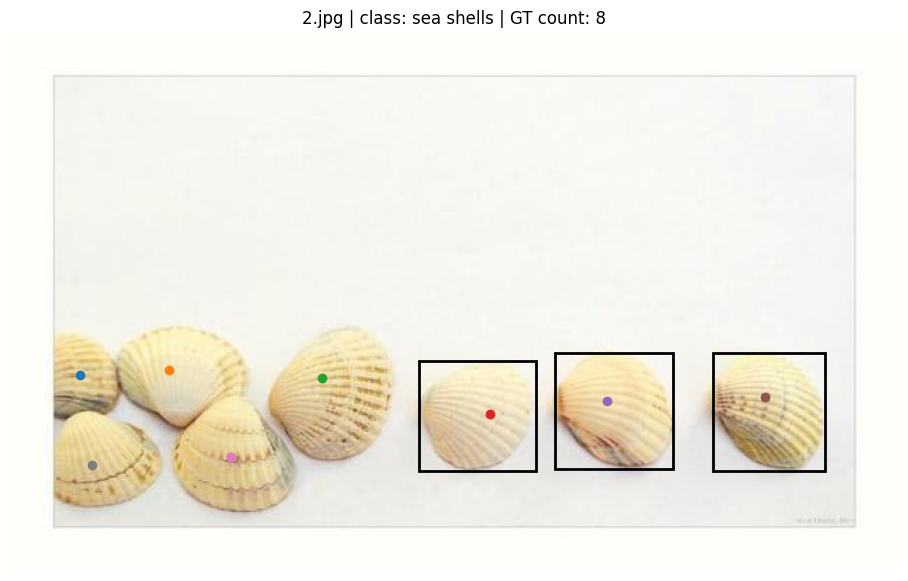

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

image_id = "2.jpg"      # also test images '7.jpg', '190.jpg', '2.jpg', "201.jpg", "902.jpg", "7700.jpg"
ann = annotations[image_id]

image_path = root / "images_384_VarV2" / image_id
img = Image.open(image_path).convert("RGB")

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(img)

# GT points
for x, y in ann["points"]:
    ax.plot(x, y, "o", markersize=6)

# Exemplar boxes
for box in ann["box_examples_coordinates"]:
    # box is stored as 4 corners
    x1, y1 = box[0]
    x2, y2 = box[2]

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        fill=False
    )
    ax.add_patch(rect)

ax.set_title(
    f"{image_id} | class: {image_to_class[image_id]} | "
    f"GT count: {len(ann['points'])}"
)
ax.axis("off")
plt.show()

In [32]:
test_ids = [
    splits["train"][0],
    splits["val"][0],
    splits["test"][0],
]

print(test_ids)

['7.jpg', '190.jpg', '2.jpg']


In [33]:
for image_id in ["201.jpg", "902.jpg", "7700.jpg"]:
    print("\n", image_id)

    print("Exists in annotations:", image_id in annotations)

    for split_name in ["train", "val", "test"]:
        if image_id in splits[split_name]:
            print("Split:", split_name)

    if image_id in image_to_class:
        print("Class:", image_to_class[image_id])


 201.jpg
Exists in annotations: True
Split: train
Class: balls

 902.jpg
Exists in annotations: True
Split: train
Class: plates

 7700.jpg
Exists in annotations: True
Split: test
Class: legos


FSC-147 — Dataset-wide integrity and statistics check

In [34]:
from pathlib import Path

image_dir = root / "images_384_VarV2"

# Actual JPG files
image_files = sorted([p.name for p in image_dir.glob("*.jpg")])
image_set = set(image_files)

# IDs from annotation JSON
annotation_set = set(annotations.keys())

# IDs from class file
class_set = set(image_to_class.keys())

print("=== FSC-147 FILE CONSISTENCY ===")
print("Image files:       ", len(image_set))
print("Annotation entries:", len(annotation_set))
print("Class entries:     ", len(class_set))

print("\nMissing image for annotation:",
      len(annotation_set - image_set))

print("Image without annotation:",
      len(image_set - annotation_set))

print("Annotation without class:",
      len(annotation_set - class_set))

print("Class without annotation:",
      len(class_set - annotation_set))

=== FSC-147 FILE CONSISTENCY ===
Image files:        6146
Annotation entries: 6146
Class entries:      6146

Missing image for annotation: 0
Image without annotation: 0
Annotation without class: 0
Class without annotation: 0


In [35]:
train_set = set(splits["train"])
val_set   = set(splits["val"])
test_set  = set(splits["test"])

print("=== SPLIT CHECK ===")
print("Train:", len(train_set))
print("Val:  ", len(val_set))
print("Test: ", len(test_set))

print("\nTrain + Val + Test:",
      len(train_set) + len(val_set) + len(test_set))

print("\nOverlap:")
print("Train ∩ Val: ", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test:  ", len(val_set & test_set))

all_split_ids = train_set | val_set | test_set

print("\nUnique images in splits:", len(all_split_ids))
print("Annotated images:       ", len(annotation_set))

print("Annotations not in main splits:",
      len(annotation_set - all_split_ids))

print("Split IDs without annotation:",
      len(all_split_ids - annotation_set))

=== SPLIT CHECK ===
Train: 3659
Val:   1286
Test:  1190

Train + Val + Test: 6135

Overlap:
Train ∩ Val:  0
Train ∩ Test: 0
Val ∩ Test:   0

Unique images in splits: 6135
Annotated images:        6146
Annotations not in main splits: 11
Split IDs without annotation: 0


In [36]:
import numpy as np

counts = []
zero_point_images = []
invalid_points = []

for image_id, ann in annotations.items():
    points = ann.get("points", [])
    counts.append(len(points))

    if len(points) == 0:
        zero_point_images.append(image_id)

    H = ann["H"]
    W = ann["W"]

    for x, y in points:
        if not (0 <= x < W and 0 <= y < H):
            invalid_points.append((image_id, x, y, W, H))

counts = np.array(counts)

print("=== GT POINT STATISTICS ===")
print("Images:", len(counts))
print("Minimum count:", counts.min())
print("Maximum count:", counts.max())
print("Mean count:   ", counts.mean())
print("Median count: ", np.median(counts))

print("\nImages with zero GT points:",
      len(zero_point_images))

print("Points outside image boundaries:",
      len(invalid_points))

=== GT POINT STATISTICS ===
Images: 6146
Minimum count: 7
Maximum count: 3701
Mean count:    55.99576960624797
Median count:  28.0

Images with zero GT points: 0
Points outside image boundaries: 21309


In [37]:
dimension_mismatches = []

for image_id, ann in annotations.items():

    expected_W = round(ann["W"] * ann["ratio_w"])
    expected_H = round(ann["H"] * ann["ratio_h"])

    with Image.open(image_dir / image_id) as img:
        actual_W, actual_H = img.size

    if (expected_W, expected_H) != (actual_W, actual_H):
        dimension_mismatches.append(
            (
                image_id,
                (expected_W, expected_H),
                (actual_W, actual_H)
            )
        )

print("Dimension mismatches:", len(dimension_mismatches))
print("First examples:", dimension_mismatches[:5])

Dimension mismatches: 0
First examples: []


In [38]:
import numpy as np

counts = []
zero_point_images = []
invalid_points = []

for image_id, ann in annotations.items():
    points = ann.get("points", [])
    counts.append(len(points))

    if len(points) == 0:
        zero_point_images.append(image_id)

    # Fast: derive resized dimensions from verified metadata
    W_img = round(ann["W"] * ann["ratio_w"])
    H_img = round(ann["H"] * ann["ratio_h"])

    for x, y in points:
        if not (0 <= x < W_img and 0 <= y < H_img):
            invalid_points.append(
                (image_id, x, y, W_img, H_img)
            )

counts = np.array(counts)

print("=== GT POINT STATISTICS ===")
print("Images:", len(counts))
print("Minimum count:", counts.min())
print("Maximum count:", counts.max())
print("Mean count:", counts.mean())
print("Median count:", np.median(counts))

print("\nImages with zero GT points:",
      len(zero_point_images))

print("Points outside resized image boundaries:",
      len(invalid_points))

=== GT POINT STATISTICS ===
Images: 6146
Minimum count: 7
Maximum count: 3701
Mean count: 55.99576960624797
Median count: 28.0

Images with zero GT points: 0
Points outside resized image boundaries: 45


In [39]:
print("Number of invalid points:", len(invalid_points))

for item in invalid_points[:20]:
    image_id, x, y, W_img, H_img = item
    print(
        f"{image_id:10s} "
        f"point=({x:.3f}, {y:.3f}) "
        f"image=({W_img}, {H_img}) "
        f"dx={x - W_img:.3f} "
        f"dy={y - H_img:.3f}"
    )

Number of invalid points: 45
1123.jpg   point=(504.000, 273.509) image=(504, 384) dx=0.000 dy=-110.491
1977.jpg   point=(576.000, 226.618) image=(576, 384) dx=0.000 dy=-157.382
1989.jpg   point=(408.000, 350.832) image=(408, 384) dx=0.000 dy=-33.168
2354.jpg   point=(384.000, 198.397) image=(384, 384) dx=0.000 dy=-185.603
2379.jpg   point=(522.000, 284.505) image=(522, 384) dx=0.000 dy=-99.495
2465.jpg   point=(0.000, 384.000) image=(577, 384) dx=-577.000 dy=0.000
2605.jpg   point=(683.000, 301.798) image=(683, 384) dx=0.000 dy=-82.202
2619.jpg   point=(490.000, 110.715) image=(490, 384) dx=0.000 dy=-273.285
2648.jpg   point=(606.000, 89.977) image=(606, 384) dx=0.000 dy=-294.023
2840.jpg   point=(578.000, 384.000) image=(578, 384) dx=0.000 dy=0.000
2840.jpg   point=(578.000, 384.000) image=(578, 384) dx=0.000 dy=0.000
2840.jpg   point=(578.000, 384.000) image=(578, 384) dx=0.000 dy=0.000
2840.jpg   point=(578.000, 384.000) image=(578, 384) dx=0.000 dy=0.000
2840.jpg   point=(578.000, 

In [40]:
equal_boundary = []
slightly_outside = []
clearly_outside = []

for image_id, x, y, W_img, H_img in invalid_points:

    # Exactly on right/bottom boundary
    if x == W_img or y == H_img:
        equal_boundary.append((image_id, x, y, W_img, H_img))

    # Within 1 pixel outside
    elif (
        -1 <= x < W_img + 1 and
        -1 <= y < H_img + 1
    ):
        slightly_outside.append((image_id, x, y, W_img, H_img))

    else:
        clearly_outside.append((image_id, x, y, W_img, H_img))

print("Exactly on boundary:", len(equal_boundary))
print("Within ~1 pixel:", len(slightly_outside))
print("Clearly outside:", len(clearly_outside))

Exactly on boundary: 44
Within ~1 pixel: 1
Clearly outside: 0


In [41]:
from collections import Counter

box_counts = []

for image_id, ann in annotations.items():
    boxes = ann.get("box_examples_coordinates", [])
    box_counts.append(len(boxes))

box_distribution = Counter(box_counts)

print("=== EXEMPLAR BOX CHECK ===")

print("Number of exemplar boxes per image:")
for n_boxes, n_images in sorted(box_distribution.items()):
    print(f"  {n_boxes} boxes: {n_images} images")

print("\nMinimum:", min(box_counts))
print("Maximum:", max(box_counts))

=== EXEMPLAR BOX CHECK ===
Number of exemplar boxes per image:
  3 boxes: 5916 images
  4 boxes: 212 images
  5 boxes: 17 images
  6 boxes: 1 images

Minimum: 3
Maximum: 6


In [42]:
from collections import Counter

class_counts = Counter(image_to_class.values())

print("=== CLASS STATISTICS ===")
print("Number of unique classes:", len(class_counts))

print("\n10 most frequent classes:")
for cls, n in class_counts.most_common(10):
    print(f"{cls:30s} {n}")

print("\n10 least frequent classes:")
for cls, n in sorted(class_counts.items(), key=lambda x: x[1])[:10]:
    print(f"{cls:30s} {n}")

=== CLASS STATISTICS ===
Number of unique classes: 147

10 most frequent classes:
beads                          423
apples                         221
geese                          216
strawberries                   169
candles                        161
chicken wings                  157
tomatoes                       156
grapes                         155
cranes                         145
bread rolls                    139

10 least frequent classes:
bottles                        1
lighters                       1
screws                         1
polka dot tiles                1
supermarket shelf              1
nails                          1
kitchen towels                 2
rice bags                      2
prawn crackers                 2
calamari rings                 2


# FSC-147 — Dataset Inspection Summary

This section records the structure and integrity checks performed on the local FSC-147 release before implementing the dataset loader. The aim is to ensure that subsequent experiments use the actual released data structure rather than assumptions about the dataset.

---

## 1. Dataset Structure

The downloaded FSC-147 release contains:

* **6,146 image files**
* **6,146 annotation records**
* **6,146 image-to-class mappings**
* **147 unique object classes**
* Adaptive ground-truth density maps (`.npy`)
* Official train / validation / test split definitions

The main files used are:

| File / Directory                     | Purpose                                                    |
| ------------------------------------ | ---------------------------------------------------------- |
| `images_384_VarV2/`                  | Resized FSC-147 images                                     |
| `annotation_FSC147_384.json`         | Point annotations, exemplar boxes, and associated metadata |
| `Train_Test_Val_FSC_147.json`        | Official dataset split definitions                         |
| `ImageClasses_FSC147.txt`            | Mapping between image IDs and object classes               |
| `gt_density_map_adaptive_384_VarV2/` | Precomputed adaptive GT density maps                       |

---

## 2. Official Train / Validation / Test Splits

The standard FSC-147 splits contain:

| Split      | Number of Images |
| ---------- | ---------------: |
| Train      |            3,659 |
| Validation |            1,286 |
| Test       |            1,190 |
| **Total**  |        **6,135** |

The three main splits have **no overlap**.

The raw release contains **6,146 images**, meaning that **11 images are not assigned to the standard train / validation / test splits**.

These 11 images will:

* remain unchanged in the raw dataset;
* **not** be manually assigned to a split;
* **not** be used in standard training or evaluation.

The split JSON also contains `val_coco` and `test_coco` entries. These are additional subset definitions and are not treated as replacements for the standard `val` and `test` splits.

---

## 3. FSC-147 Annotation Fields

Inspection of `annotation_FSC147_384.json` showed the following fields for each image:

| Field                      | Meaning                                                                | Use in This Project                                                  |
| -------------------------- | ---------------------------------------------------------------------- | -------------------------------------------------------------------- |
| `H`, `W`                   | Original image dimensions                                              | Useful metadata / verification                                       |
| `ratio_h`, `ratio_w`       | Scaling factors from original dimensions to the released resized image | Useful for coordinate/dimension verification                         |
| `points`                   | Ground-truth target-object locations                                   | **Essential**                                                        |
| `box_examples_coordinates` | Bounding boxes around a small number of exemplar objects               | Preserve separately as `exemplar_boxes`; not used as zero-shot input |
| `box_examples_path`        | Authors' original path to exemplar crops                               | Not required                                                         |
| `img_path`                 | Authors' original image path                                           | Not required; local path is constructed                              |
| `density_path`             | Authors' original adaptive density-map path                            | Original path not required                                           |
| `density_path_fixed`       | Alternative/fixed density-map path                                     | Not currently required                                               |
| `r`                        | Preprocessing / density-related parameter                              | Not currently required                                               |
| Adaptive `.npy` file       | Precomputed GT density map                                             | Optional; useful for density-based experiments/baselines             |

---

## 4. Ground-Truth Point Annotations

Each target object is represented by **one ground-truth point**.

Therefore, for an FSC-147 image:

[
\text{GT count} = |\text{points}|
]

Equivalent Python expression:

```
gt_count = len(annotation["points"])
```

The points should be interpreted as **object-instance location annotations**.

They should **not** be assumed to be mathematically calculated centroids of segmentation masks, because FSC-147 does not provide GT segmentation masks for these instances.

Partially visible target objects can also be annotated. Therefore, if a partially visible target object has a GT point, it contributes **one object** to the benchmark ground-truth count.

Dataset-wide point statistics observed in the local release:

| Statistic                  |  Value |
| -------------------------- | -----: |
| Images                     |  6,146 |
| Minimum GT count           |      7 |
| Maximum GT count           |  3,701 |
| Mean GT count              | ≈ 56.0 |
| Median GT count            |     28 |
| Images with zero GT points |      0 |

---

## 5. Exemplar Boxes

`box_examples_coordinates` contains bounding boxes around a **small subset of target objects**.

These are **exemplar boxes**, rather than ground-truth bounding boxes for every object in the image.

They support the exemplar/few-shot counting setting: a model can be shown several examples of the object to be counted.

Dataset-wide inspection found:

| Number of Exemplar Boxes | Number of Images |
| -----------------------: | ---------------: |
|                        3 |            5,916 |
|                        4 |              212 |
|                        5 |               17 |
|                        6 |                1 |

Thus, although most FSC-147 images contain **3 exemplar boxes**, the number is not always three and should not be hard-coded.

### Relevance to this project

The primary project setting is **zero-shot counting**. Therefore, FSC-147 exemplar boxes should **not be supplied to the proposed zero-shot pipeline as inference guidance**, because this would introduce exemplar/few-shot information.

However, they should be preserved separately in the loader because they may still be useful for:

* reproducing exemplar-based FSC-147 baselines;
* diagnostic experiments;
* comparison or ablation experiments;
* future analysis.

Importantly:

**FSC-147 exemplar boxes are not equivalent to complete per-instance GT bounding-box annotations.**

---

## 6. Image Dimensions and Coordinate Verification

The annotation JSON contains original image dimensions:

`H`, `W`

together with scaling factors:

`ratio_h`, `ratio_w`

The expected resized dimensions are therefore approximately:

[
H_{\text{resized}} = H \times ratio_h
]

[
W_{\text{resized}} = W \times ratio_w
]

These values were compared against the actual dimensions of the images stored in `images_384_VarV2/`.

**Result: 0 dimension mismatches.**

Therefore, the scaling metadata is consistent with the released resized images.

---

## 7. Point-Boundary Integrity Check

A first boundary check incorrectly compared the GT point coordinates against the original `H` and `W`, producing a large number of apparent out-of-bound points.

The check was corrected to use the **actual dimensions of the resized images**.

After correction:

* **45 points** failed a strict zero-based pixel-index check;
* **44 points** lie exactly on an image boundary;
* **1 point** lies within approximately one pixel of the boundary;
* **0 points** are materially outside the image.

For example, for an image with width `576`, a coordinate of:

```
x = 576
```

lies exactly on the geometric right boundary, although the largest valid zero-based array index would be `575`.

These cases are therefore treated as **boundary-coordinate conventions rather than corrupted annotations**.

### Loader policy

The original floating-point GT coordinates should be preserved unchanged.

If a downstream model requires integer pixel indices, coordinate conversion or clamping should be performed explicitly during that model's preprocessing stage, for example:

```
x_idx = min(max(round(x), 0), width - 1)
y_idx = min(max(round(y), 0), height - 1)
```

The raw annotations themselves should not be modified.

---

## 8. Dataset Integrity Result

The local FSC-147 release passed the main consistency checks:

| Check                             | Result |
| --------------------------------- | -----: |
| Image files                       |  6,146 |
| Annotation entries                |  6,146 |
| Class mappings                    |  6,146 |
| Missing images for annotations    |      0 |
| Images without annotations        |      0 |
| Annotations without class labels  |      0 |
| Classes without annotations       |      0 |
| Unique classes                    |    147 |
| Train / Val overlap               |      0 |
| Train / Test overlap              |      0 |
| Val / Test overlap                |      0 |
| Images with zero GT points        |      0 |
| Resized-dimension mismatches      |      0 |
| Materially out-of-image GT points |      0 |

**Conclusion:** the FSC-147 release is internally consistent and suitable for use after respecting the official train / validation / test split definitions.

---

## 9. Proposed FSC-147 Loader Representation

For the common dataset interface, an FSC-147 sample should eventually be represented approximately as:

```
{
    "image_id": str,
    "image_path": str,
    "image": PIL.Image | None,
    "width": int | None,
    "height": int | None,

    "categories": {
        "<class_name>": {
            "points": [[x, y], ...],
            "boxes": [],
            "count": int
        }
    },

    "exemplar_boxes": [...],

    "dataset": "fsc147",
    "split": "train" | "val" | "test"
}
```

### Important semantic distinction

Within the future common FSC-147 / OmniCount-191 schema:

* `points` = per-instance GT point annotations;
* `boxes` = reserved for **per-instance GT bounding boxes**, if provided by a dataset;
* `exemplar_boxes` = few-shot exemplar boxes provided by FSC-147.

Therefore, FSC-147 should currently have:

```
"boxes": []
```

rather than placing `box_examples_coordinates` into `boxes`.

This distinction is important because exemplar boxes and complete ground-truth instance boxes have different meanings and should not be conflated.

---

## 10. Status Before Implementing the Final Common Loader

**FSC-147 inspection: COMPLETE**

The current common FSC-147 / OmniCount-191 loader remains **provisional**.

Before finalising the shared loader:

1. Inspect the actual OmniCount-191 release.
2. Verify its image and annotation structure.
3. Verify its class/category representation.
4. Verify the semantics and format of its point annotations.
5. Verify whether its bounding boxes are complete per-instance GT annotations.
6. Verify its official split structure.
7. Perform visual sanity checks.
8. Perform dataset-wide integrity and statistical checks.
9. Only then finalise the common FSC-147 / OmniCount-191 sample schema.

This avoids designing the common loader around assumptions about OmniCount-191 before inspecting the actual released data.


**OmniCount-191 dataset load, unzip and inspection**

In [43]:
!ls -lh "/content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets"

total 1.4G
drwx------ 3 root root 4.0K Aug 18 15:58 FSC147
drwx------ 2 root root 4.0K Aug 18 20:19 OmniCount-191
-rw------- 1 root root 1.4G Aug 18 19:51 OmniCount-191.zip


In [44]:
DATA_ROOT = "/content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets"

zip_path = f"{DATA_ROOT}/OmniCount-191.zip"
extract_path = f"{DATA_ROOT}/"

if not os.path.exists(f"{DATA_ROOT}/OmniCount-191"):

  !unzip -q "$zip_path" -d "$extract_path"
  print("Extraction complete.")

else:
  print("OmniCount-191 already extracted.")
  print("Skipping extraction.")


OmniCount-191 already extracted.
Skipping extraction.


In [45]:
from pathlib import Path

omni_root = Path(f"{DATA_ROOT}/OmniCount-191")

all_files = [p for p in omni_root.rglob("*") if p.is_file()]
all_dirs  = [p for p in omni_root.rglob("*") if p.is_dir()]

print("Total directories:", len(all_dirs))
print("Total files:", len(all_files))

Total directories: 33
Total files: 30284


In [46]:
jpg_files  = list(omni_root.rglob("*.jpg"))
json_files = list(omni_root.rglob("*.json"))

print("JPG images:", len(jpg_files))
print("JSON files:", len(json_files))

JPG images: 30230
JSON files: 49


In [47]:
expected_categories = {
    "Birds",
    "Fruits",
    "Household",
    "Pets",
    "Satellite",
    "Supermarket",
    "Urban",
    "Vegetables",
    "Wild",
}

actual_categories = {
    p.name for p in omni_root.iterdir()
    if p.is_dir()
}

print("Missing categories:", expected_categories - actual_categories)
print("Unexpected directories:", actual_categories - expected_categories)

Missing categories: set()
Unexpected directories: set()


In [49]:
from collections import defaultdict

split_summary = {}

for category in sorted(expected_categories):
    category_dir = omni_root / category
    split_summary[category] = {}

    for split in ["train", "valid", "test"]:
        split_dir = category_dir / split

        if not split_dir.exists():
            split_summary[category][split] = {
                "exists": False,
                "images": 0,
                "jsons": 0
            }
            continue

        images = list(split_dir.glob("*.jpg"))
        jsons = list(split_dir.glob("*.json"))

        split_summary[category][split] = {
            "exists": True,
            "images": len(images),
            "jsons": len(jsons)
        }

print("=== OmniCount-191 Split Structure ===")

for category, info in split_summary.items():
    print(f"\n{category}")
    for split in ["train", "valid", "test"]:
        s = info[split]

        if s["exists"]:
            print(
                f"  {split:5s}: "
                f"{s['images']:5d} images | "
                f"{s['jsons']:2d} JSON files"
            )
        else:
            print(f"  {split:5s}: MISSING")

=== OmniCount-191 Split Structure ===

Birds
  train:    25 images |  2 JSON files
  valid:     5 images |  2 JSON files
  test :    10 images |  2 JSON files

Fruits
  train:  2424 images |  2 JSON files
  valid:   303 images |  2 JSON files
  test :   303 images |  2 JSON files

Household
  train:   361 images |  2 JSON files
  valid: MISSING
  test : MISSING

Pets
  train:    33 images |  2 JSON files
  valid:    15 images |  2 JSON files
  test :    11 images |  2 JSON files

Satellite
  train:  2607 images |  2 JSON files
  valid:   254 images |  2 JSON files
  test :   127 images |  2 JSON files

Supermarket
  train:  5241 images |  2 JSON files
  valid:   492 images |  2 JSON files
  test :   251 images |  2 JSON files

Urban
  train:  7000 images |  2 JSON files
  valid:  2000 images |  2 JSON files
  test :  1000 images |  2 JSON files

Vegetables
  train:   329 images |  2 JSON files
  valid:     2 images |  2 JSON files
  test : MISSING

Wild
  train:  6675 images |  2 JSON 

In [50]:
# check *.json (for one category (Birds))

import json
from pathlib import Path

# Start with one category / split
category = "Birds"
split = "test"

split_dir = omni_root / category / split

print("Directory:", split_dir)
print("\nJSON files:")

json_files = sorted(split_dir.glob("*.json"))

for json_path in json_files:
    print(" -", json_path.name)

Directory: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets/OmniCount-191/Birds/test

JSON files:
 - _annotations.coco.json
 - birds_vae_test.json


In [51]:
# check all json level structure

for json_path in json_files:

    print("\n" + "=" * 60)
    print("FILE:", json_path.name)

    with open(json_path, "r") as f:
        data = json.load(f)

    print("Python type:", type(data))

    if isinstance(data, dict):
        print("Top-level keys:", data.keys())

        for key, value in data.items():
            print(
                f"  {key}: "
                f"type={type(value).__name__}",
                f"length={len(value) if hasattr(value, '__len__') else 'N/A'}"
            )

    elif isinstance(data, list):
        print("Number of entries:", len(data))

        if len(data) > 0:
            print("First entry type:", type(data[0]))

            if isinstance(data[0], dict):
                print("First entry keys:", data[0].keys())


FILE: _annotations.coco.json
Python type: <class 'dict'>
Top-level keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
  info: type=dict length=6
  licenses: type=list length=1
  categories: type=list length=3
  images: type=list length=10
  annotations: type=list length=165

FILE: birds_vae_test.json
Python type: <class 'list'>
Number of entries: 10
First entry type: <class 'dict'>
First entry keys: dict_keys(['id', 'image', 'conversations'])


In [52]:
# check _annotations.coco.json

coco_path = split_dir / "_annotations.coco.json"

with open(coco_path, "r") as f:
    coco = json.load(f)

print("=== CATEGORIES ===")
print(coco["categories"])

print("\n=== FIRST IMAGE ===")
print(coco["images"][0])

print("\n=== FIRST ANNOTATION ===")
print(coco["annotations"][0])

=== CATEGORIES ===
[{'id': 1, 'name': 'crow', 'supercategory': 'birds-pigeons-crows'}, {'id': 2, 'name': 'pigeon', 'supercategory': 'birds-pigeons-crows'}, {'id': 3, 'name': 'raven', 'supercategory': 'birds-pigeons-crows'}]

=== FIRST IMAGE ===
{'id': 0, 'license': 1, 'file_name': 'birds_train_mp4-38_jpg.rf.24d8ad4c5677ad8505334c4652599ce4.jpg', 'height': 1080, 'width': 1920, 'date_captured': '2024-02-19T21:54:01+00:00'}

=== FIRST ANNOTATION ===
{'id': 0, 'image_id': 0, 'category_id': 2, 'bbox': [476, 508, 81, 56], 'area': 4536, 'segmentation': [], 'iscrowd': 0}


In [53]:
# check birds_vae_test.json

vae_path = split_dir / "birds_vae_test.json"

with open(vae_path, "r") as f:
    vae_data = json.load(f)

print("=== FIRST VAE ENTRY ===")

first = vae_data[0]

print("id:", first.get("id"))
print("image:", first.get("image"))
print("conversations:")

for conv in first.get("conversations", []):
    print(conv)

=== FIRST VAE ENTRY ===
id: 0
image: birds_train_mp4-38_jpg.rf.24d8ad4c5677ad8505334c4652599ce4.jpg
conversations:
{'from': 'human', 'value': ' Pigeon: 10, Crow: 2, Raven: 5'}
{'from': 'gpt', 'value': 'pigeon: [0.248, 0.470, 0.290, 0.522], pigeon: [0.374, 0.530, 0.415, 0.567], pigeon: [0.334, 0.494, 0.358, 0.531], pigeon: [0.320, 0.724, 0.391, 0.772], pigeon: [0.392, 0.738, 0.448, 0.806], pigeon: [0.404, 0.669, 0.441, 0.737], pigeon: [0.445, 0.642, 0.496, 0.711], pigeon: [0.491, 0.606, 0.563, 0.641], pigeon: [0.397, 0.627, 0.440, 0.669], pigeon: [0.478, 0.640, 0.533, 0.709], crow: [0.215, 0.518, 0.277, 0.588], crow: [0.513, 0.544, 0.565, 0.583], raven: [0.447, 0.434, 0.468, 0.491], raven: [0.391, 0.377, 0.436, 0.454], raven: [0.681, 0.465, 0.710, 0.562], raven: [0.472, 0.485, 0.537, 0.557], raven: [0.322, 0.625, 0.368, 0.676]'}


Check id, image_id, category_id struture across folders / domain.  

In [59]:
# check different Folders whether the id structures are the same -->
# Confirmed all id, image_id, category_id are local.
# category_id is a local identifier for a category/class.
# The category record maps category_id -> category name and supercategory.
# loop all expected_categories

import json

def inspect_coco_file(category, split):
    split_dir = omni_root / category / split
    coco_path = split_dir / "_annotations.coco.json"

    with open(coco_path, "r") as f:
        coco = json.load(f)

    image_ids = [img["id"] for img in coco["images"]]
    annotation_ids = [ann["id"] for ann in coco["annotations"]]
    category_ids = [cat["id"] for cat in coco["categories"]]

    print(f"\n=== {category}/{split} ===")
    print("Images:", len(coco["images"]))
    print("Image ID range:", min(image_ids), "to", max(image_ids))

    print("Annotations:", len(coco["annotations"]))
    print("Annotation ID range:",
          min(annotation_ids), "to", max(annotation_ids))

    print("Categories:", len(coco["categories"]))
    print("Category IDs:", category_ids)

    print("Category names:")
    for cat in coco["categories"]:
        print(
            f"  id={cat['id']}: "
            f"{cat['name']} "
            f"(supercategory={cat.get('supercategory')})"
        )

for category in expected_categories:
    for split in ["train", "valid", "test"]:
      if (omni_root / category / split).exists():
        inspect_coco_file(category, split)
      if not (omni_root / category / split).exists():
        print(f"{category}/{split} does not exist")




=== Urban/train ===
Images: 7000
Image ID range: 0 to 6999
Annotations: 37279
Annotation ID range: 0 to 37278
Categories: 13
Category IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Category names:
  id=0: autonomousvehicle (supercategory=none)
  id=1: bike (supercategory=autonomousvehicle)
  id=2: biker (supercategory=autonomousvehicle)
  id=3: bus (supercategory=autonomousvehicle)
  id=4: car (supercategory=autonomousvehicle)
  id=5: motorbike (supercategory=autonomousvehicle)
  id=6: motorbiker (supercategory=autonomousvehicle)
  id=7: pedestrian (supercategory=autonomousvehicle)
  id=8: trafficlight (supercategory=autonomousvehicle)
  id=9: trafficlight_green (supercategory=autonomousvehicle)
  id=10: trafficlight_red (supercategory=autonomousvehicle)
  id=11: trafficlight_yellow (supercategory=autonomousvehicle)
  id=12: truck (supercategory=autonomousvehicle)

=== Urban/valid ===
Images: 2000
Image ID range: 0 to 1999
Annotations: 10889
Annotation ID range: 0 to 10888
Categories

check bbox, area, segmentation, iscrowd across all folders / domain

In [63]:
# Inspect one sample image + annotation from every available COCO file

for category in sorted(expected_categories):
    for split in ["train", "valid", "test"]:

        split_dir = omni_root / category / split

        print(f"\n=== {category}/{split} ===")

        # Some OmniCount-191 categories do not contain all three splits
        if not split_dir.exists():
            print("MISSING")
            continue

        coco_path = split_dir / "_annotations.coco.json"

        with open(coco_path, "r") as f:
            coco = json.load(f)

        # Compact category mapping
        category_map = {
            cat["id"]: cat["name"]
            for cat in coco["categories"]
        }

        print("Categories:", category_map)

        # First image
        img = coco["images"][0]
        print(
            "First image:",
            f"id={img['id']}, "
            f"file={img['file_name']}, "
            f"size={img['width']}x{img['height']}"
        )

        # First annotation
        ann = coco["annotations"][0]
        print(
            "First annotation:",
            f"id={ann['id']}, "
            f"image_id={ann['image_id']}, "
            f"category_id={ann['category_id']}, "
            f"bbox={ann['bbox']}, "
            f"area={ann['area']}, "
            f"segmentation={ann['segmentation']}, "
            f"iscrowd={ann['iscrowd']}"
        )



=== Birds/train ===
Categories: {1: 'crow', 2: 'pigeon', 3: 'raven'}
First image: id=0, file=birds_train_mp4-14_jpg.rf.15061a38d958ed08395af4d3e1f2a128.jpg, size=1920x1080
First annotation: id=0, image_id=0, category_id=3, bbox=[43, 391, 84.784, 133.683], area=11334.213, segmentation=[[42.908, 508.072, 52.629, 449.248, 69.202, 408.265, 80.9, 418.023, 106.246, 407.289, 115.994, 390.701, 127.692, 470.716, 98.447, 459.006, 67.252, 507.796, 53.604, 524.384]], iscrowd=0

=== Birds/valid ===
Categories: {1: 'crow', 2: 'pigeon', 3: 'raven'}
First image: id=0, file=birds_train_mp4-4_jpg.rf.370c7eec9b601e0f432d51bc85dca5f8.jpg, size=1920x1080
First annotation: id=0, image_id=0, category_id=2, bbox=[635, 488, 73.87, 63.03], area=4656.026, segmentation=[], iscrowd=0

=== Birds/test ===
Categories: {1: 'crow', 2: 'pigeon', 3: 'raven'}
First image: id=0, file=birds_train_mp4-38_jpg.rf.24d8ad4c5677ad8505334c4652599ce4.jpg, size=1920x1080
First annotation: id=0, image_id=0, category_id=2, bbox=[476,

dataset-wide COCO annotation integrity check - bbox, area, segmentation, and iscrowd,

In [64]:
import json
from collections import Counter, defaultdict

print("=== OmniCount-191 COCO Annotation Integrity Check ===")

summary = []

for category in sorted(expected_categories):
    for split in ["train", "valid", "test"]:

        split_dir = omni_root / category / split
        coco_path = split_dir / "_annotations.coco.json"

        if not coco_path.exists():
            continue

        with open(coco_path, "r") as f:
            coco = json.load(f)

        images_by_id = {
            img["id"]: img
            for img in coco["images"]
        }

        categories_by_id = {
            cat["id"]: cat
            for cat in coco["categories"]
        }

        total_annotations = len(coco["annotations"])

        invalid_image_refs = 0
        invalid_category_refs = 0

        invalid_bbox_length = 0
        nonpositive_bbox = 0
        bbox_outside_image = 0

        area_mismatch = 0

        empty_segmentation = 0
        nonempty_segmentation = 0

        iscrowd_counts = Counter()

        for ann in coco["annotations"]:

            # ------------------------------------------------------------
            # 1. Reference integrity
            # ------------------------------------------------------------
            image_id = ann["image_id"]
            category_id = ann["category_id"]

            if image_id not in images_by_id:
                invalid_image_refs += 1
                continue

            if category_id not in categories_by_id:
                invalid_category_refs += 1

            # ------------------------------------------------------------
            # 2. Bounding box checks
            # COCO format = [x, y, width, height]
            # ------------------------------------------------------------
            bbox = ann.get("bbox", [])

            if len(bbox) != 4:
                invalid_bbox_length += 1
                continue

            x, y, w, h = bbox

            if w <= 0 or h <= 0:
                nonpositive_bbox += 1

            img = images_by_id[image_id]
            W = img["width"]
            H = img["height"]

            # Small floating-point tolerance
            eps = 1e-6

            if (
                x < -eps
                or y < -eps
                or x + w > W + eps
                or y + h > H + eps
            ):
                bbox_outside_image += 1

            # ------------------------------------------------------------
            # 3. Area check
            # ------------------------------------------------------------
            area = ann.get("area", None)

            if area is not None:
                bbox_area = w * h

                # Relative tolerance because some values are floating point
                tolerance = max(1e-3, abs(bbox_area) * 1e-5)

                if abs(area - bbox_area) > tolerance:
                    area_mismatch += 1

            # ------------------------------------------------------------
            # 4. Segmentation
            # ------------------------------------------------------------
            segmentation = ann.get("segmentation", [])

            if segmentation:
                nonempty_segmentation += 1
            else:
                empty_segmentation += 1

            # ------------------------------------------------------------
            # 5. COCO crowd flag
            # ------------------------------------------------------------
            iscrowd_counts[ann.get("iscrowd", None)] += 1

        summary.append({
            "category": category,
            "split": split,
            "images": len(coco["images"]),
            "annotations": total_annotations,
            "invalid_image_refs": invalid_image_refs,
            "invalid_category_refs": invalid_category_refs,
            "invalid_bbox_length": invalid_bbox_length,
            "nonpositive_bbox": nonpositive_bbox,
            "bbox_outside_image": bbox_outside_image,
            "area_mismatch": area_mismatch,
            "empty_segmentation": empty_segmentation,
            "nonempty_segmentation": nonempty_segmentation,
            "iscrowd": dict(iscrowd_counts),
        })

# ------------------------------------------------------------------------
# Compact output
# ------------------------------------------------------------------------

for s in summary:
    print(f"\n=== {s['category']}/{s['split']} ===")

    print(
        f"Images={s['images']} | "
        f"Annotations={s['annotations']}"
    )

    print(
        f"Bad refs: image={s['invalid_image_refs']}, "
        f"category={s['invalid_category_refs']}"
    )

    print(
        f"BBox: bad_length={s['invalid_bbox_length']}, "
        f"nonpositive={s['nonpositive_bbox']}, "
        f"outside_image={s['bbox_outside_image']}"
    )

    print(
        f"Area mismatches={s['area_mismatch']}"
    )

    print(
        f"Segmentation: "
        f"empty={s['empty_segmentation']}, "
        f"nonempty={s['nonempty_segmentation']}"
    )

    print(
        f"iscrowd={s['iscrowd']}"
    )

=== OmniCount-191 COCO Annotation Integrity Check ===

=== Birds/train ===
Images=25 | Annotations=342
Bad refs: image=0, category=0
BBox: bad_length=0, nonpositive=0, outside_image=1
Area mismatches=0
Segmentation: empty=334, nonempty=8
iscrowd={0: 342}

=== Birds/valid ===
Images=5 | Annotations=76
Bad refs: image=0, category=0
BBox: bad_length=0, nonpositive=0, outside_image=0
Area mismatches=0
Segmentation: empty=73, nonempty=3
iscrowd={0: 76}

=== Birds/test ===
Images=10 | Annotations=165
Bad refs: image=0, category=0
BBox: bad_length=0, nonpositive=0, outside_image=0
Area mismatches=0
Segmentation: empty=163, nonempty=2
iscrowd={0: 165}

=== Fruits/train ===
Images=2424 | Annotations=11444
Bad refs: image=0, category=0
BBox: bad_length=0, nonpositive=0, outside_image=0
Area mismatches=0
Segmentation: empty=11444, nonempty=0
iscrowd={0: 11444}

=== Fruits/valid ===
Images=303 | Annotations=1429
Bad refs: image=0, category=0
BBox: bad_length=0, nonpositive=0, outside_image=0
Area 

check Area mismatchs and outside_image

In [65]:
# Inspect OmniCount-191 annotation anomalies:
# - bounding boxes outside image bounds
# - area != bbox width * height

outside_examples = []
area_mismatch_examples = []

for category in sorted(expected_categories):
    for split in ["train", "valid", "test"]:

        coco_path = omni_root / category / split / "_annotations.coco.json"

        if not coco_path.exists():
            continue

        with open(coco_path, "r") as f:
            coco = json.load(f)

        images_by_id = {
            img["id"]: img
            for img in coco["images"]
        }

        for ann in coco["annotations"]:

            img = images_by_id[ann["image_id"]]

            W = img["width"]
            H = img["height"]

            x, y, w, h = ann["bbox"]

            # --------------------------------------------------------
            # Out-of-image bbox
            # --------------------------------------------------------
            dx_left   = -x
            dy_top    = -y
            dx_right  = x + w - W
            dy_bottom = y + h - H

            if (
                x < 0
                or y < 0
                or x + w > W
                or y + h > H
            ):
                outside_examples.append({
                    "domain": category,
                    "split": split,
                    "ann_id": ann["id"],
                    "image_id": ann["image_id"],
                    "file": img["file_name"],
                    "image_size": (W, H),
                    "bbox": ann["bbox"],
                    "overflow": {
                        "left": max(0, dx_left),
                        "top": max(0, dy_top),
                        "right": max(0, dx_right),
                        "bottom": max(0, dy_bottom),
                    }
                })

            # --------------------------------------------------------
            # Area mismatch
            # --------------------------------------------------------
            bbox_area = w * h
            area = ann["area"]

            tolerance = max(1e-3, abs(bbox_area) * 1e-5)

            if abs(area - bbox_area) > tolerance:
                area_mismatch_examples.append({
                    "domain": category,
                    "split": split,
                    "ann_id": ann["id"],
                    "image_id": ann["image_id"],
                    "file": img["file_name"],
                    "bbox": ann["bbox"],
                    "bbox_area": bbox_area,
                    "stored_area": area,
                    "difference": area - bbox_area,
                    "segmentation_empty": not bool(
                        ann.get("segmentation", [])
                    )
                })


print("=== OUT-OF-IMAGE BBOXES ===")
print("Total:", len(outside_examples))

for item in outside_examples[:25]:
    print(item)


print("\n=== AREA MISMATCHES ===")
print("Total:", len(area_mismatch_examples))

for item in area_mismatch_examples[:20]:
    print(item)

=== OUT-OF-IMAGE BBOXES ===
Total: 17
{'domain': 'Birds', 'split': 'train', 'ann_id': 39, 'image_id': 2, 'file': 'birds_train_mp4-8_jpg.rf.1a233db1ea30c921200b1b288ba4294d.jpg', 'image_size': (1920, 1080), 'bbox': [1872, 652, 48.31, 75.76], 'overflow': {'left': 0, 'top': 0, 'right': 0.30999999999994543, 'bottom': 0}}
{'domain': 'Wild', 'split': 'train', 'ann_id': 106, 'image_id': 32, 'file': 'assp_jpeg_jpg.rf.1bdfa2813ede5ae88eaabda085777b53.jpg', 'image_size': (640, 640), 'bbox': [241, 319, 234.444, 321.372], 'overflow': {'left': 0, 'top': 0, 'right': 0, 'bottom': 0.37200000000007094}}
{'domain': 'Wild', 'split': 'train', 'ann_id': 5072, 'image_id': 1488, 'file': 'assp_jpeg_jpg.rf.dd8f29b6b40e3ca37577acba99cf41d0.jpg', 'image_size': (640, 640), 'bbox': [231, 325, 234.625, 315.136], 'overflow': {'left': 0, 'top': 0, 'right': 0, 'bottom': 0.13599999999996726}}
{'domain': 'Wild', 'split': 'train', 'ann_id': 6735, 'image_id': 1988, 'file': 'cinghiali-trionfale-3_jpg.rf.a9d4c60f582a16db4fc

In [66]:
# Summarise the 168 area mismatches

abs_diffs = [
    abs(x["difference"])
    for x in area_mismatch_examples
]

relative_diffs = [
    abs(x["difference"]) / x["bbox_area"]
    for x in area_mismatch_examples
    if x["bbox_area"] > 0
]

with_segmentation = sum(
    not x["segmentation_empty"]
    for x in area_mismatch_examples
)

print("=== AREA MISMATCH SUMMARY ===")
print("Total mismatches:", len(area_mismatch_examples))
print("Maximum absolute difference:", max(abs_diffs))
print("Mean absolute difference:", sum(abs_diffs) / len(abs_diffs))

print("Maximum relative difference:",
      max(relative_diffs) * 100, "%")

print(
    "With non-empty segmentation:",
    with_segmentation,
    "/",
    len(area_mismatch_examples)
)

=== AREA MISMATCH SUMMARY ===
Total mismatches: 168
Maximum absolute difference: 0.10087399999974878
Mean absolute difference: 0.016673148809539105
Maximum relative difference: 0.02055709733786276 %
With non-empty segmentation: 168 / 168


✓ image references valid
✓ category references valid
✓ bbox format valid
✓ bbox widths/heights positive
✓ all iscrowd = 0
✓ only 17 boxes marginally (<0.5 px) outside boundaries
✓ segmentation optional and sparse
✓ area generally matches bbox area
✓ quantify the 168 tiny area differences


Visual Sanity check

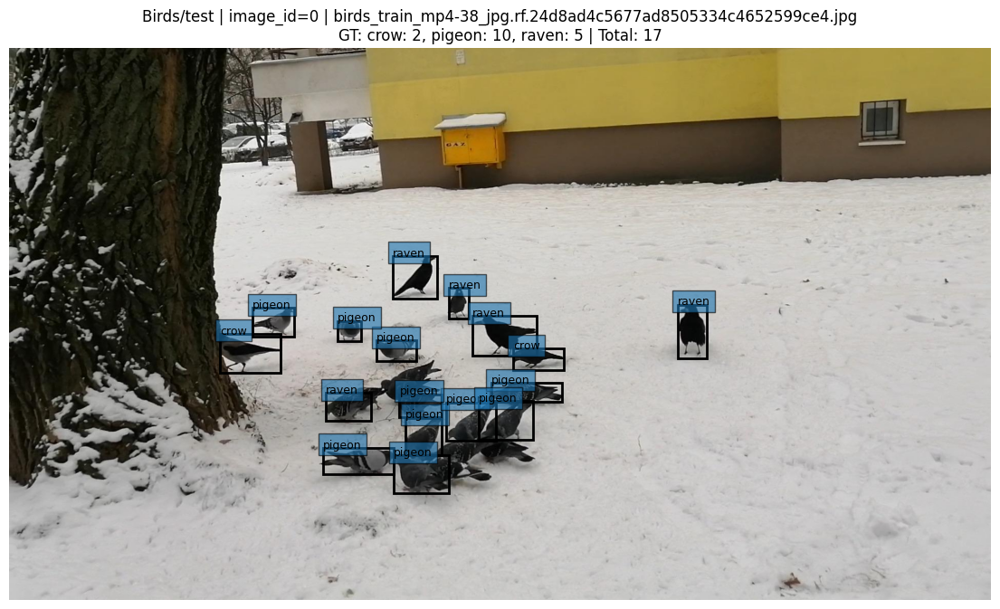

In [70]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter


# ------------------------------------------------------------
# Select one OmniCount-191 image
# ------------------------------------------------------------

category = "Birds"
split = "test"
image_id = 0          # local COCO image_id


# ------------------------------------------------------------
# Load COCO annotation file
# ------------------------------------------------------------

split_dir = omni_root / category / split
coco_path = split_dir / "_annotations.coco.json"

with open(coco_path, "r") as f:
    coco = json.load(f)


# ------------------------------------------------------------
# Build lookup tables
# ------------------------------------------------------------

images_by_id = {
    img["id"]: img
    for img in coco["images"]
}

categories_by_id = {
    cat["id"]: cat["name"]
    for cat in coco["categories"]
}


# ------------------------------------------------------------
# Get selected image and its annotations
# ------------------------------------------------------------

img_info = images_by_id[image_id]

image_annotations = [
    ann for ann in coco["annotations"]
    if ann["image_id"] == image_id
]

image_path = split_dir / img_info["file_name"]
img = Image.open(image_path).convert("RGB")


# ------------------------------------------------------------
# Count GT objects per class
# ------------------------------------------------------------

class_counts = Counter(
    categories_by_id[ann["category_id"]]
    for ann in image_annotations
)


# ------------------------------------------------------------
# Visualise image + GT bounding boxes
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)

for ann in image_annotations:

    # COCO bbox format: [x, y, width, height]
    x, y, w, h = ann["bbox"]

    class_name = categories_by_id[ann["category_id"]]

    rect = patches.Rectangle(
        (x, y),
        w,
        h,
        linewidth=2,
        fill=False
    )

    ax.add_patch(rect)

    # Add class label
    ax.text(
        x,
        y,
        class_name,
        fontsize=9,
        bbox=dict(alpha=0.6)
    )


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

count_text = ", ".join(
    f"{name}: {count}"
    for name, count in sorted(class_counts.items())
)

ax.set_title(
    f"{category}/{split} | "
    f"image_id={image_id} | "
    f"{img_info['file_name']}\n"
    f"GT: {count_text} | "
    f"Total: {len(image_annotations)}"
)

ax.axis("off")
plt.show()


=== GT COUNTS ===
crow: 2
pigeon: 10
raven: 5
Total: 17


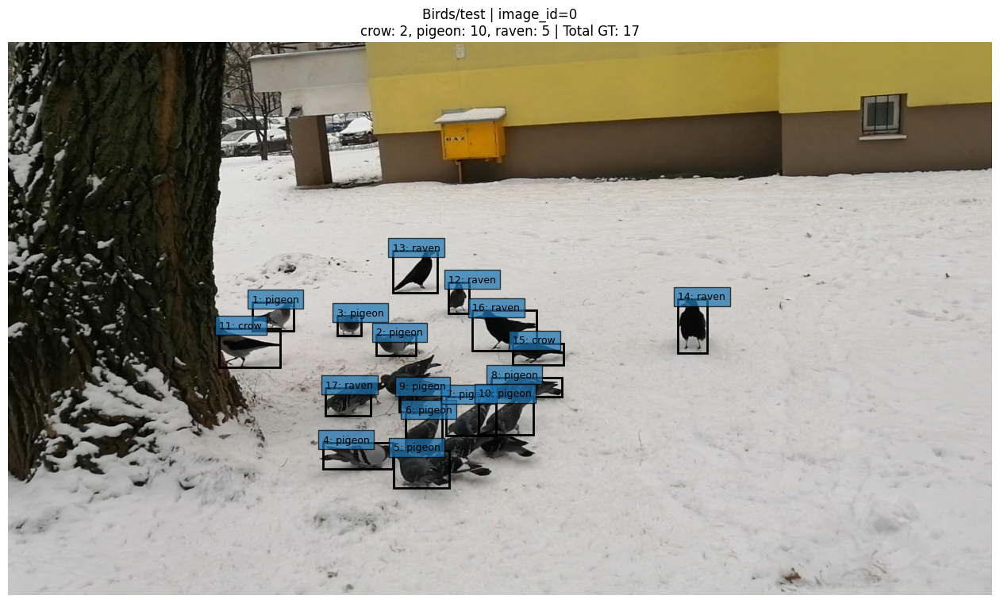

In [71]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

# ------------------------------------------------------------
# Select image
# ------------------------------------------------------------

category = "Birds"
split = "test"
image_id = 0

split_dir = omni_root / category / split
coco_path = split_dir / "_annotations.coco.json"

with open(coco_path, "r") as f:
    coco = json.load(f)

images_by_id = {
    img["id"]: img
    for img in coco["images"]
}

categories_by_id = {
    cat["id"]: cat["name"]
    for cat in coco["categories"]
}

img_info = images_by_id[image_id]

image_annotations = [
    ann for ann in coco["annotations"]
    if ann["image_id"] == image_id
]

image_path = split_dir / img_info["file_name"]
img = Image.open(image_path).convert("RGB")


# ------------------------------------------------------------
# GT counts
# ------------------------------------------------------------

class_counts = Counter(
    categories_by_id[ann["category_id"]]
    for ann in image_annotations
)

print("=== GT COUNTS ===")
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count}")

print("Total:", len(image_annotations))


# ------------------------------------------------------------
# Plot numbered boxes
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(img)

for i, ann in enumerate(image_annotations, start=1):

    x, y, w, h = ann["bbox"]
    class_name = categories_by_id[ann["category_id"]]

    rect = patches.Rectangle(
        (x, y),
        w,
        h,
        linewidth=2,
        fill=False
    )
    ax.add_patch(rect)

    ax.text(
        x,
        y,
        f"{i}: {class_name}",
        fontsize=9,
        bbox=dict(alpha=0.7)
    )

ax.set_title(
    f"{category}/{split} | image_id={image_id}\n"
    + ", ".join(
        f"{name}: {count}"
        for name, count in sorted(class_counts.items())
    )
    + f" | Total GT: {len(image_annotations)}"
)

ax.axis("off")
plt.show()

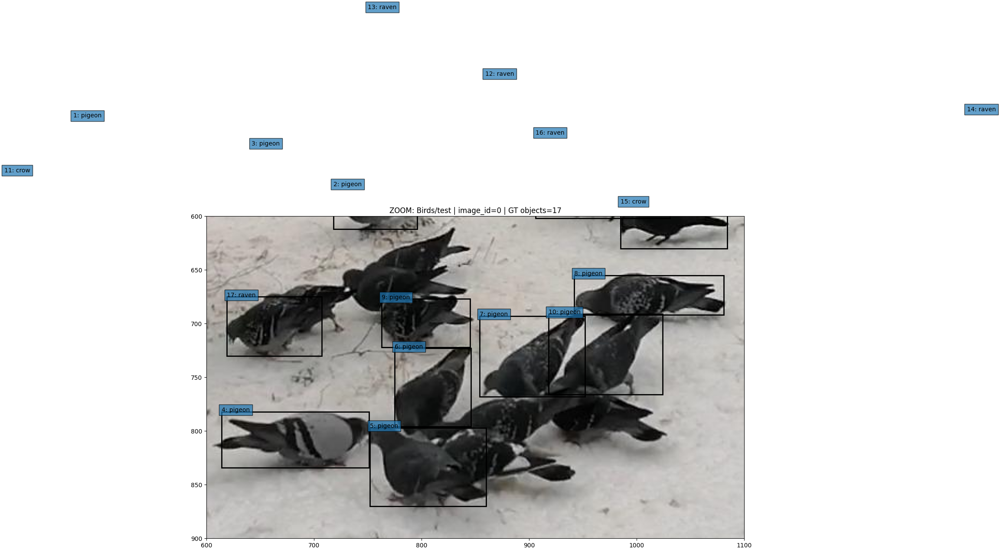

In [76]:
# ------------------------------------------------------------
# Zoom into dense bird cluster
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(img)

for i, ann in enumerate(image_annotations, start=1):

    x, y, w, h = ann["bbox"]
    class_name = categories_by_id[ann["category_id"]]

    rect = patches.Rectangle(
        (x, y),
        w,
        h,
        linewidth=2,
        fill=False
    )
    ax.add_patch(rect)

    ax.text(
        x,
        y,
        f"{i}: {class_name}",
        fontsize=10,
        bbox=dict(alpha=0.7)
    )

# Adjust these if needed after seeing the crop
ax.set_xlim(600, 1100)
ax.set_ylim(900, 600)

ax.set_title(
    f"ZOOM: {category}/{split} | image_id={image_id} | "
    f"GT objects={len(image_annotations)}"
)

plt.show()

In [77]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter


def show_omnicount_gt(category, split, image_id):

    split_dir = omni_root / category / split
    coco_path = split_dir / "_annotations.coco.json"

    with open(coco_path, "r") as f:
        coco = json.load(f)

    images_by_id = {
        img["id"]: img
        for img in coco["images"]
    }

    categories_by_id = {
        cat["id"]: cat["name"]
        for cat in coco["categories"]
    }

    img_info = images_by_id[image_id]

    image_annotations = [
        ann for ann in coco["annotations"]
        if ann["image_id"] == image_id
    ]

    image_path = split_dir / img_info["file_name"]
    img = Image.open(image_path).convert("RGB")

    class_counts = Counter(
        categories_by_id[ann["category_id"]]
        for ann in image_annotations
    )

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(img)

    for i, ann in enumerate(image_annotations, start=1):

        x, y, w, h = ann["bbox"]
        class_name = categories_by_id[ann["category_id"]]

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            fill=False
        )
        ax.add_patch(rect)

        ax.text(
            x,
            y,
            f"{i}: {class_name}",
            fontsize=8,
            bbox=dict(alpha=0.7)
        )

    count_text = ", ".join(
        f"{name}: {count}"
        for name, count in sorted(class_counts.items())
    )

    ax.set_title(
        f"{category}/{split} | image_id={image_id}\n"
        f"GT: {count_text} | Total GT: {len(image_annotations)}"
    )

    ax.axis("off")
    plt.show()

Sampled image IDs: [1, 0, 4, 9, 6]


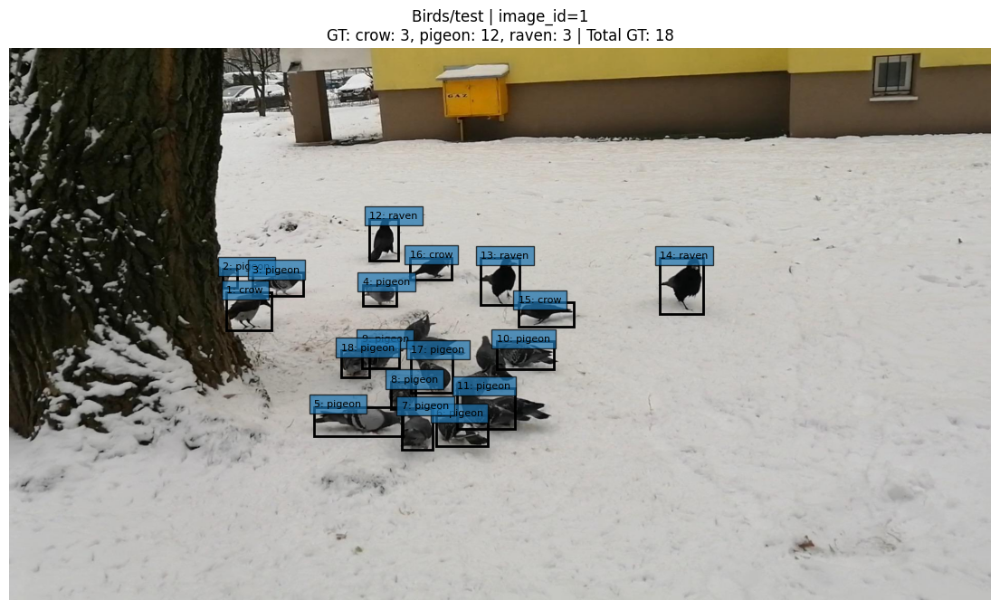

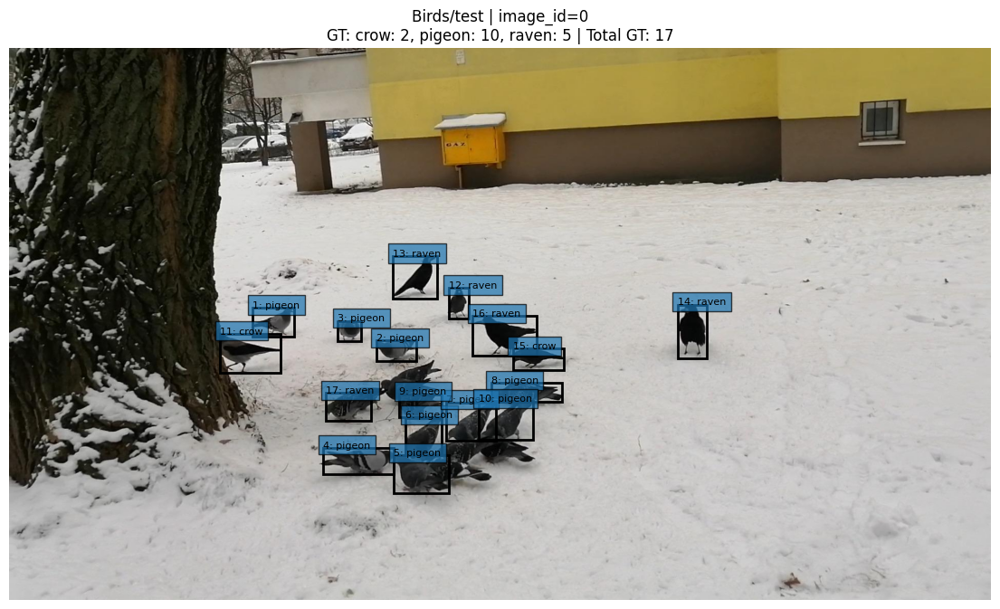

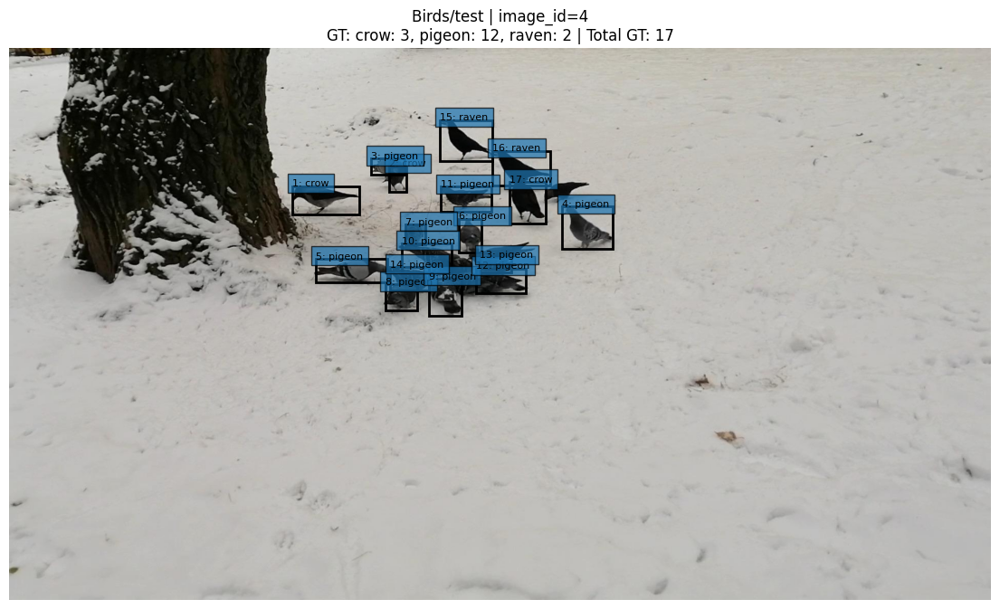

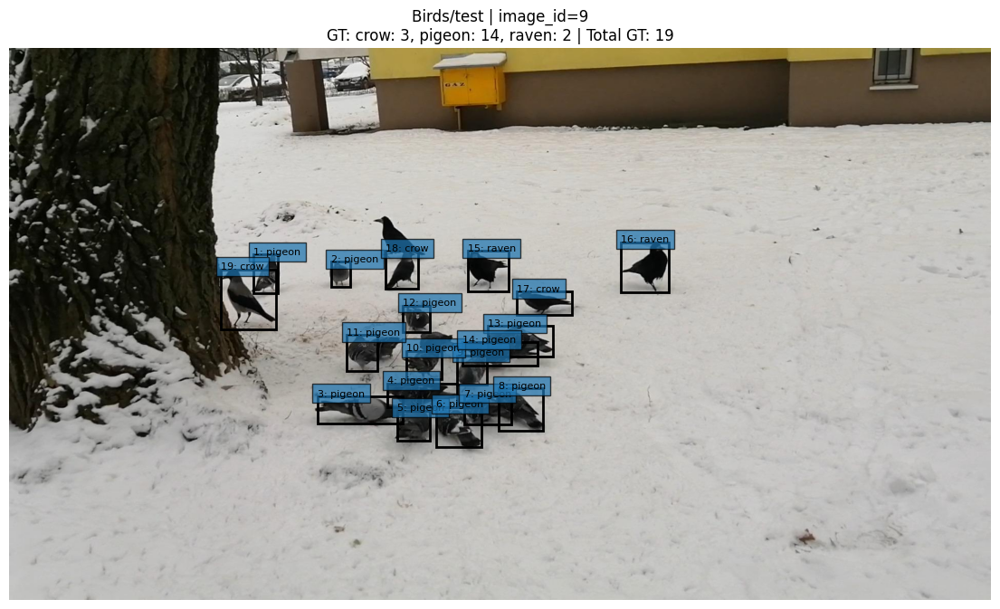

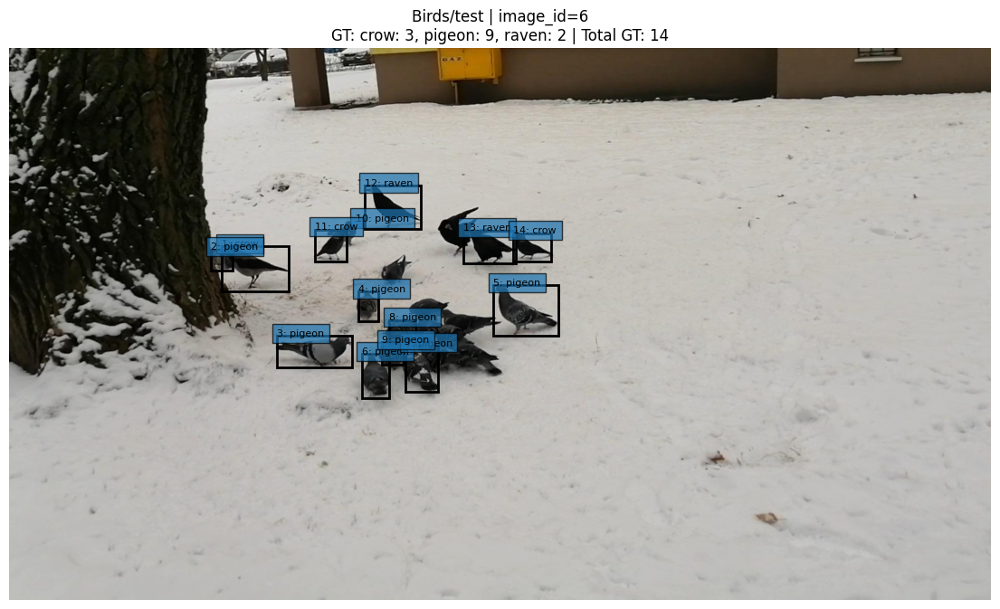

In [78]:
category = "Birds"
split = "test"

split_dir = omni_root / category / split

with open(split_dir / "_annotations.coco.json", "r") as f:
    coco = json.load(f)

all_image_ids = [img["id"] for img in coco["images"]]

random.seed(42)       # reproducible for dissertation work
sample_ids = random.sample(all_image_ids, 5)

print("Sampled image IDs:", sample_ids)

for image_id in sample_ids:
    show_omnicount_gt(category, split, image_id)


Urban/test sampled IDs: [654, 114, 25]


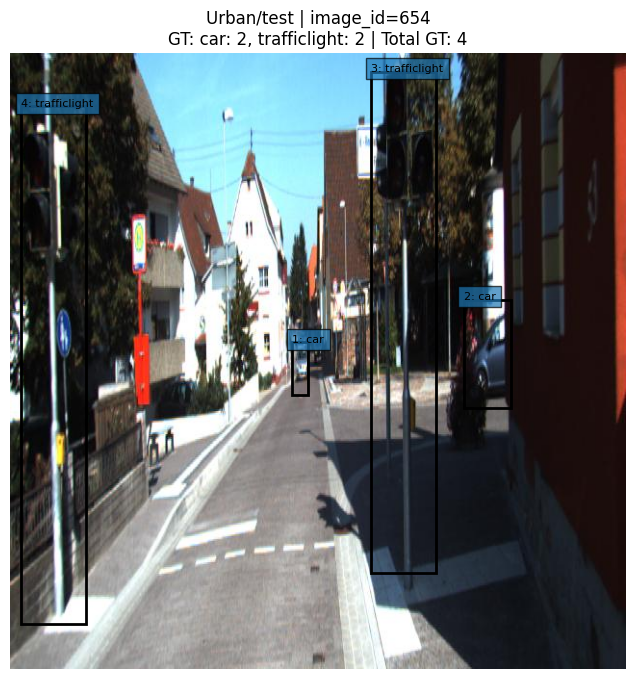

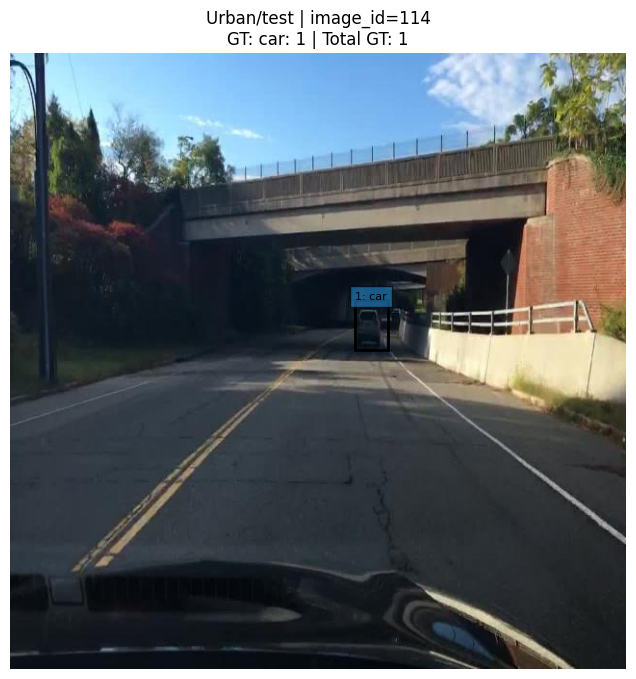

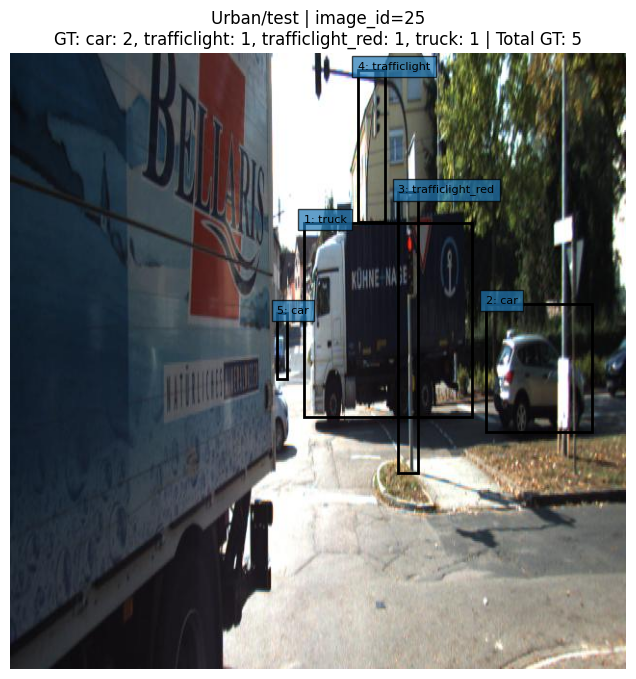


Pets/test sampled IDs: [4, 3, 9]


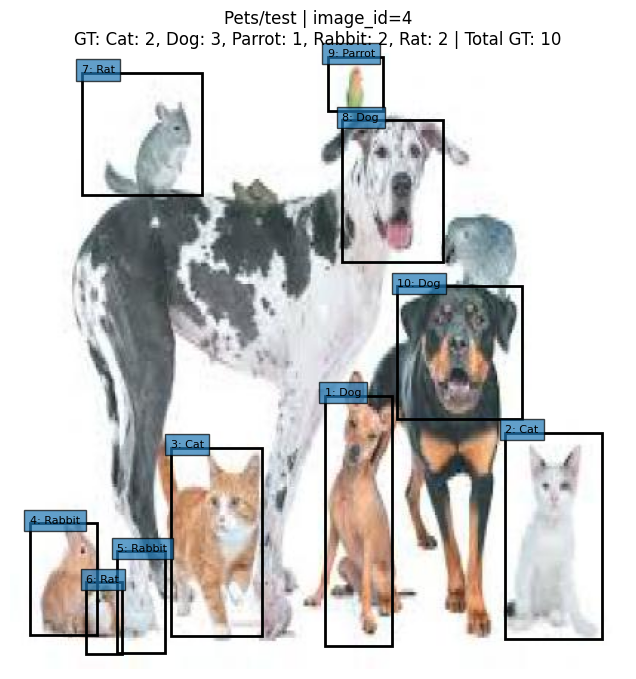

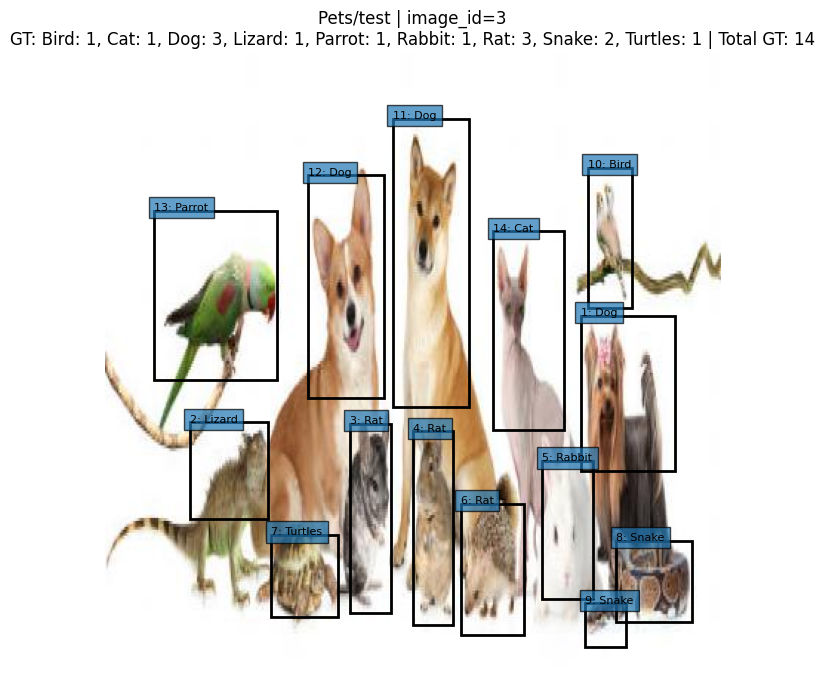

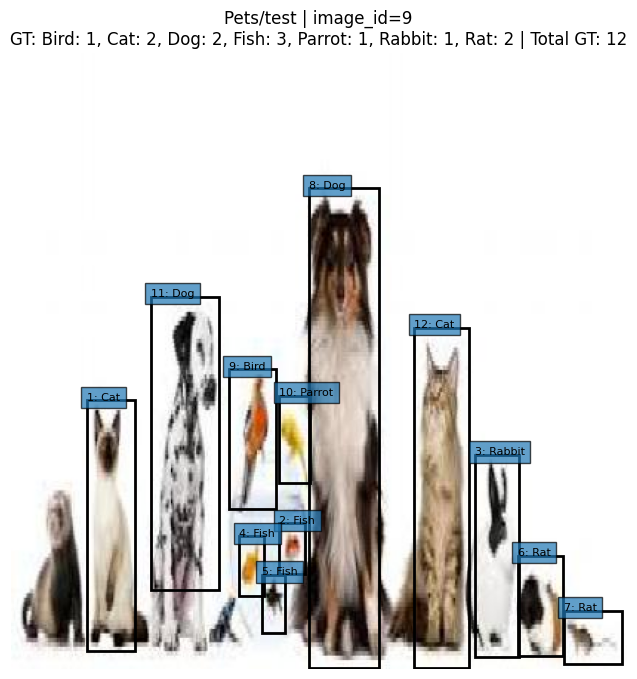


Household/test: MISSING — skipped

Birds/test sampled IDs: [2, 1, 8]


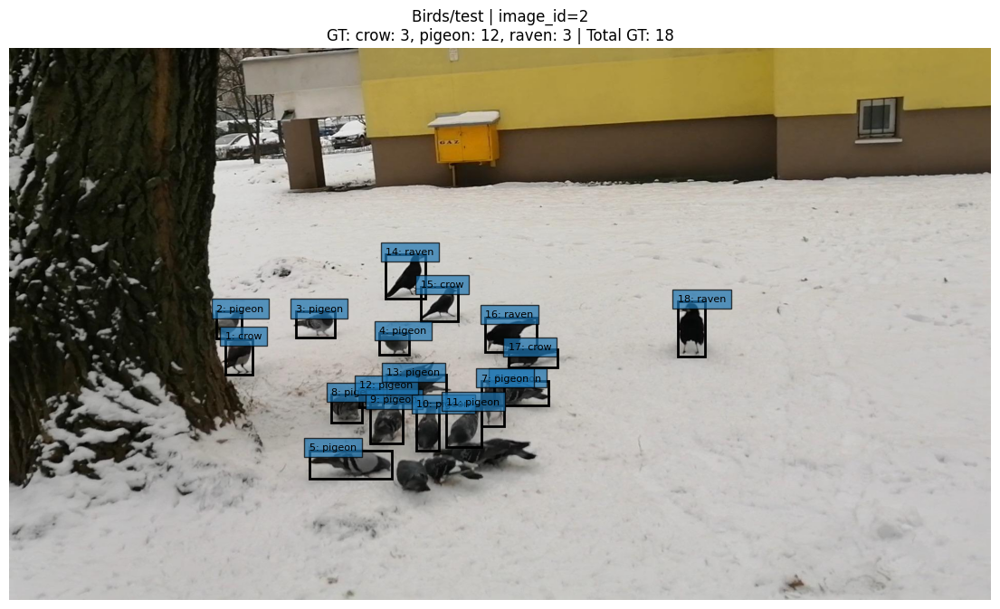

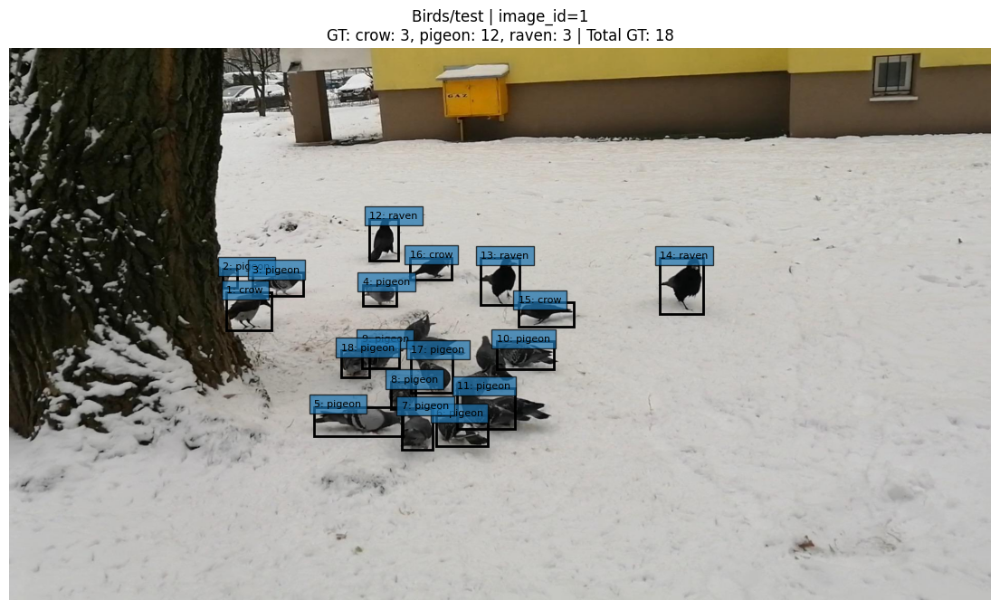

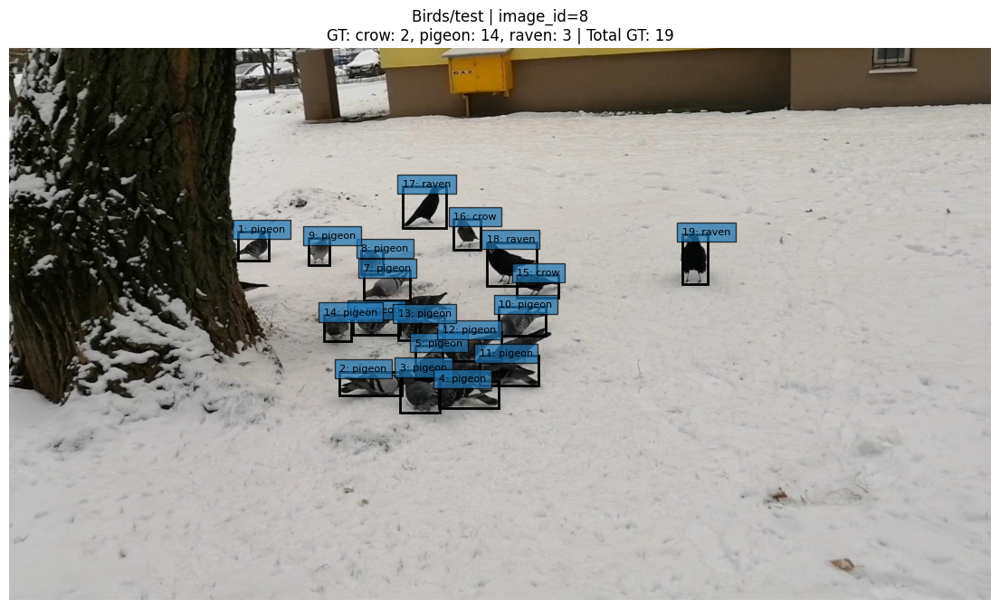


Wild/test sampled IDs: [151, 108, 8]


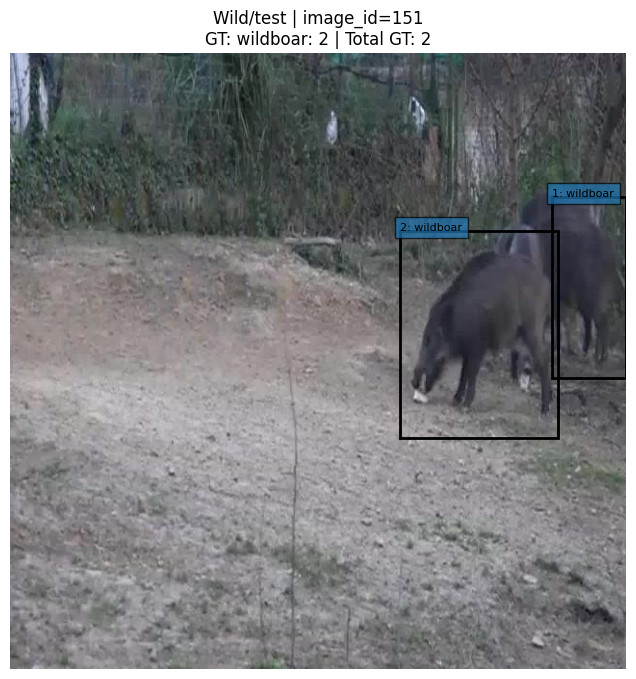

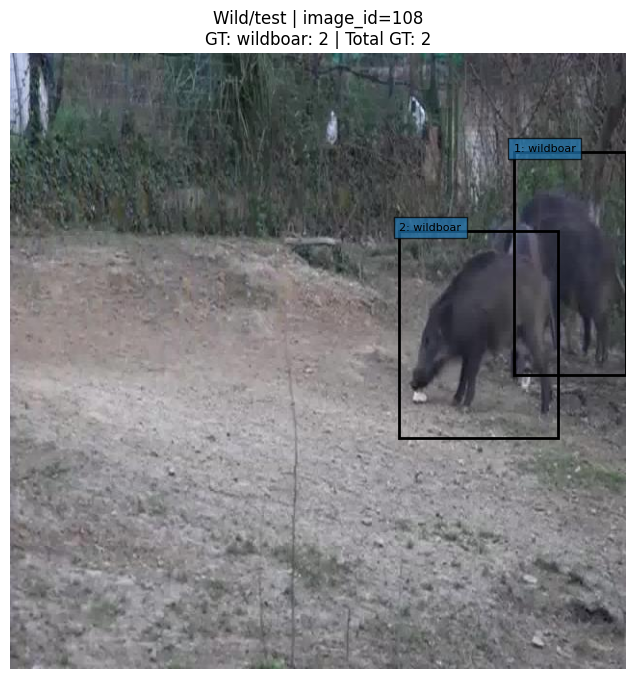

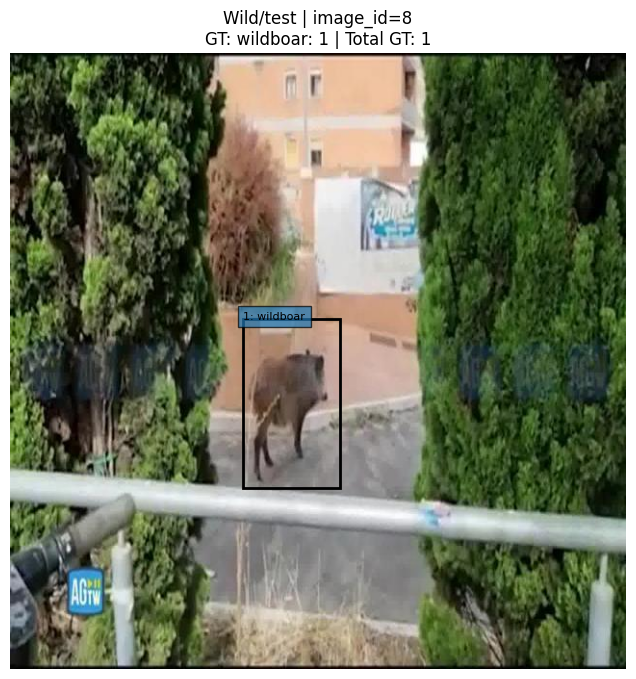


Supermarket/test sampled IDs: [7, 23, 55]


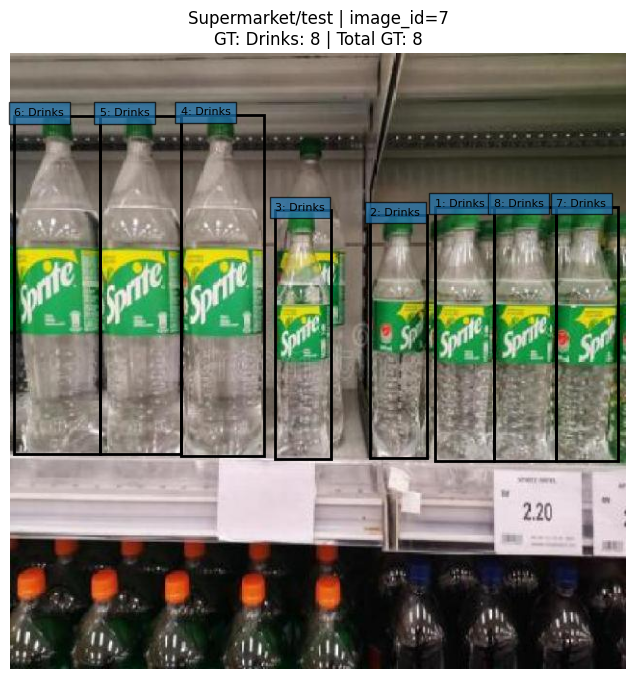

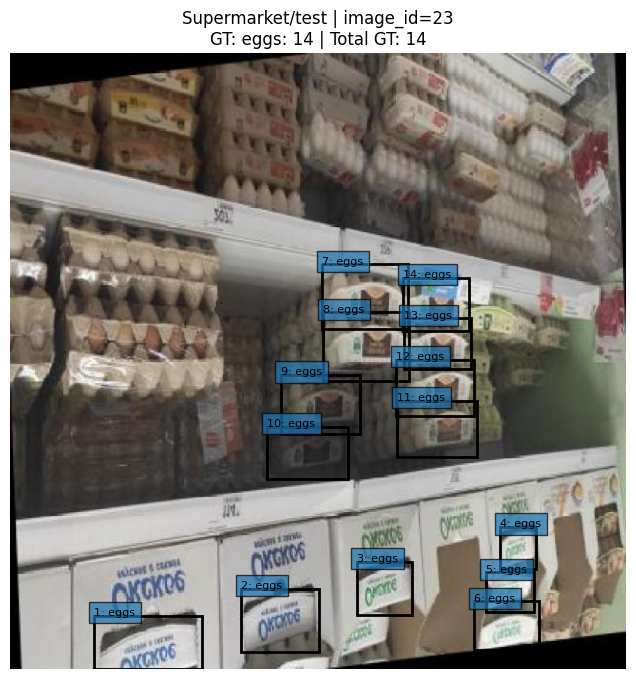

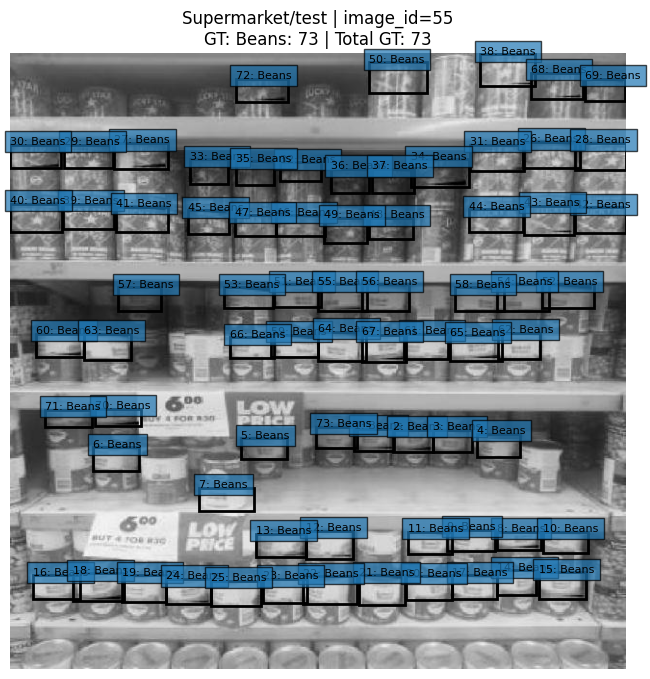


Satellite/test sampled IDs: [29, 64, 77]


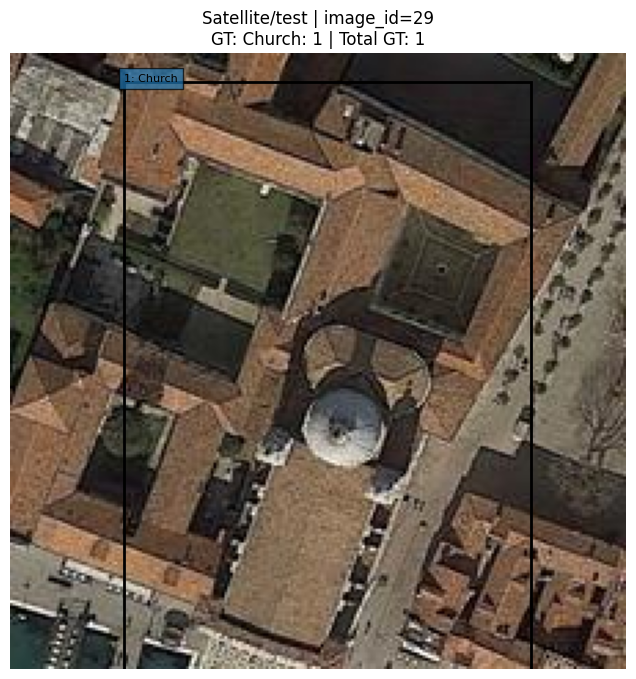

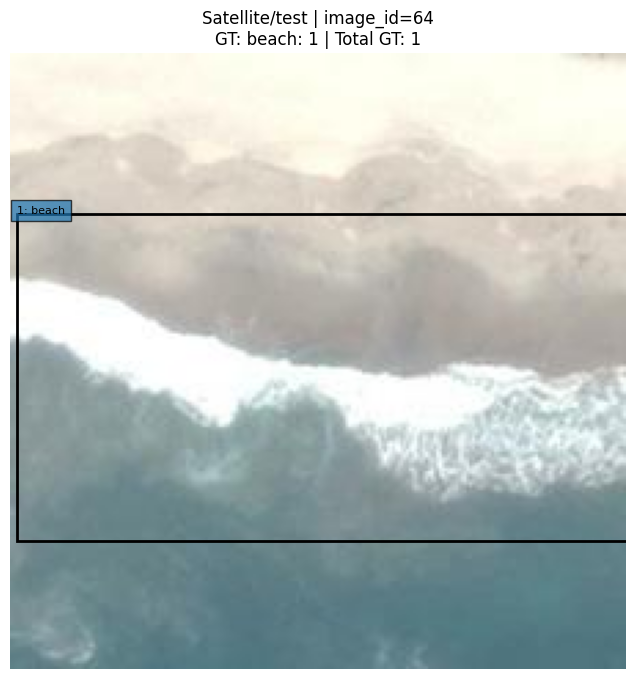

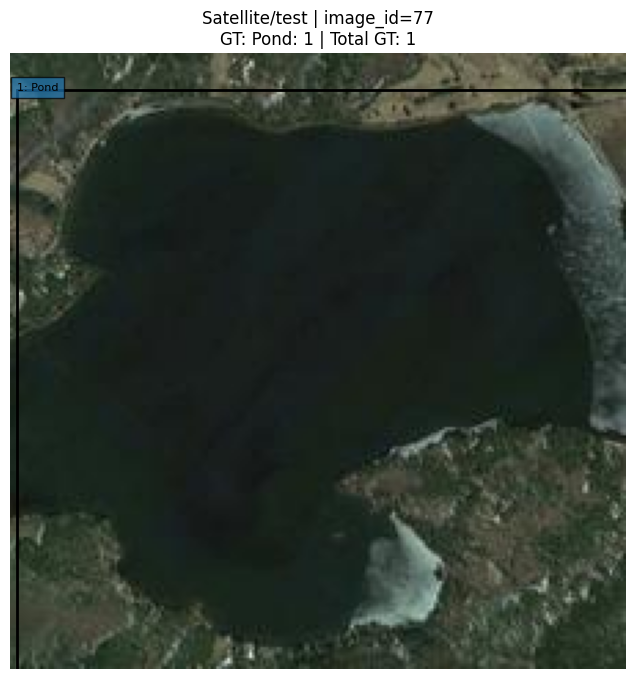


Fruits/test sampled IDs: [13, 287, 101]


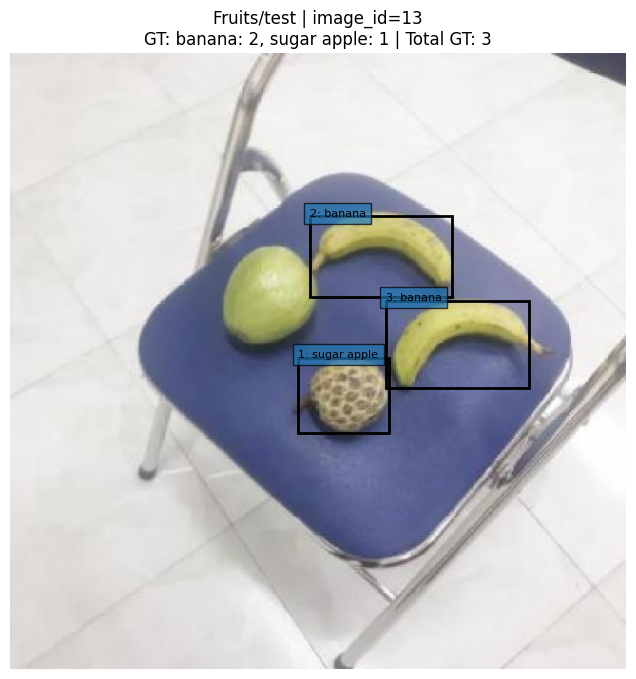

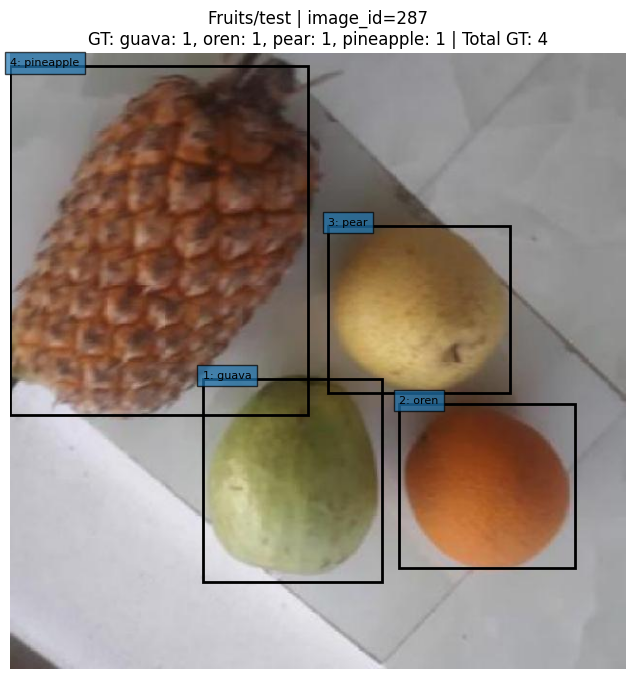

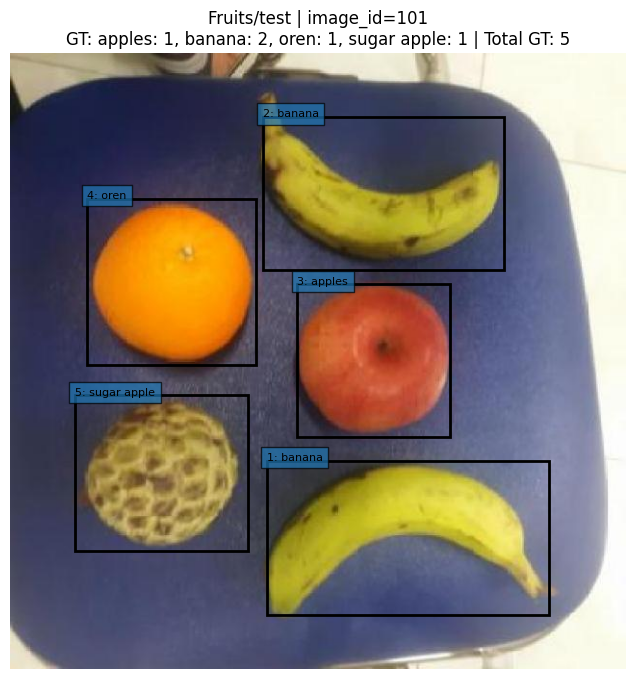


Vegetables/test: MISSING — skipped


In [79]:
import random
import json

random.seed(42)

n_samples = 3

for category in expected_categories:

    split = "test"
    split_dir = omni_root / category / split
    coco_path = split_dir / "_annotations.coco.json"

    # Some OmniCount domains do not have a test split
    if not coco_path.exists():
        print(f"\n{category}/test: MISSING — skipped")
        continue

    with open(coco_path, "r") as f:
        coco = json.load(f)

    all_image_ids = [img["id"] for img in coco["images"]]

    sample_ids = random.sample(
        all_image_ids,
        min(n_samples, len(all_image_ids))
    )

    print(f"\n{category}/test sampled IDs: {sample_ids}")

    for image_id in sample_ids:
        show_omnicount_gt(category, split, image_id)

**Findings:**


**OmniCount-191's COCO annotations are structurally valid, but visual inspection suggests that bounding-box annotations may not always exhaustively cover every visible instance. This appears particularly noticeable in some dense or highly clustered scenes (e.g. Birds and Supermarket).**

**Check Dataset Statistics**

In [82]:
# ============================================================
# OmniCount-191 — Dataset Statistics
# ============================================================

import json
import numpy as np
import pandas as pd
from collections import Counter, defaultdict


def get_omnicount_stats(category, split):
    split_dir = omni_root / category / split
    coco_path = split_dir / "_annotations.coco.json"

    if not coco_path.exists():
        return None

    with open(coco_path, "r") as f:
        coco = json.load(f)

    images = coco["images"]
    annotations = coco["annotations"]
    categories = coco["categories"]

    # --------------------------------------------------------
    # Lookup tables
    # --------------------------------------------------------

    image_lookup = {img["id"]: img for img in images}

    anns_by_image = defaultdict(list)

    for ann in annotations:
        anns_by_image[ann["image_id"]].append(ann)

    # --------------------------------------------------------
    # Objects per image
    # --------------------------------------------------------

    objects_per_image = [
        len(anns_by_image[img["id"]])
        for img in images
    ]

    # --------------------------------------------------------
    # Number of labels/classes per image
    # --------------------------------------------------------

    labels_per_image = [
        len(set(
            ann["category_id"]
            for ann in anns_by_image[img["id"]]
        ))
        for img in images
    ]

    single_label_images = sum(n == 1 for n in labels_per_image)
    multi_label_images = sum(n > 1 for n in labels_per_image)
    zero_annotation_images = sum(n == 0 for n in objects_per_image)

    # --------------------------------------------------------
    # Image dimensions
    # --------------------------------------------------------

    image_widths = [img["width"] for img in images]
    image_heights = [img["height"] for img in images]

    # --------------------------------------------------------
    # Bounding-box statistics
    #
    # COCO bbox = [x, y, width, height]
    #
    # Normalised quantities make boxes comparable across
    # different image resolutions.
    # --------------------------------------------------------

    bbox_width_rel = []
    bbox_height_rel = []
    bbox_area_rel = []

    for ann in annotations:

        img = image_lookup[ann["image_id"]]

        img_w = img["width"]
        img_h = img["height"]

        _, _, bbox_w, bbox_h = ann["bbox"]

        bbox_width_rel.append(bbox_w / img_w)
        bbox_height_rel.append(bbox_h / img_h)
        bbox_area_rel.append(
            (bbox_w * bbox_h) / (img_w * img_h)
        )

    # --------------------------------------------------------
    # Return one summary row
    # --------------------------------------------------------

    return {
        "Folder": category,
        "Split": split,

        "Images": len(images),
        "Classes": len(categories),
        "Objects": len(annotations),

        "Obj/Image Mean": np.mean(objects_per_image),
        "Obj/Image Median": np.median(objects_per_image),
        "Obj/Image Min": np.min(objects_per_image),
        "Obj/Image Max": np.max(objects_per_image),

        "Single-label Images": single_label_images,
        "Multi-label Images": multi_label_images,
        "Zero-object Images": zero_annotation_images,

        "Image Width Mean": np.mean(image_widths),
        "Image Height Mean": np.mean(image_heights),

        "BBox Width Rel Mean": np.mean(bbox_width_rel),
        "BBox Height Rel Mean": np.mean(bbox_height_rel),
        "BBox Area Rel Mean": np.mean(bbox_area_rel),
        "BBox Area Rel Median": np.median(bbox_area_rel),
    }


# ============================================================
# Run over all folders / splits
# ============================================================

stats = []

for category in expected_categories:
    for split in ["train", "valid", "test"]:

        result = get_omnicount_stats(category, split)

        if result is not None:
            stats.append(result)


stats_df = pd.DataFrame(stats)

# Make output easier to read
pd.set_option("display.max_columns", None)

display(
    stats_df.round({
        "Obj/Image Mean": 2,
        "Obj/Image Median": 1,
        "Image Width Mean": 1,
        "Image Height Mean": 1,
        "BBox Width Rel Mean": 4,
        "BBox Height Rel Mean": 4,
        "BBox Area Rel Mean": 4,
        "BBox Area Rel Median": 4,
    })
)

,Folder,Split,Images,Classes,Objects,Obj/Image Mean,Obj/Image Median,Obj/Image Min,Obj/Image Max,Single-label Images,Multi-label Images,Zero-object Images,Image Width Mean,Image Height Mean,BBox Width Rel Mean,BBox Height Rel Mean,BBox Area Rel Mean,BBox Area Rel Median
0,Urban,train,7000,13,37279,5.33,5.0,1,21,3640,3360,0,640.0,640.0,0.0871,0.1836,0.0219,0.0087
1,Urban,valid,2000,13,10889,5.44,5.0,1,20,1034,966,0,640.0,640.0,0.0870,0.1852,0.0218,0.0089
2,Urban,test,1000,13,5352,5.35,5.0,1,21,525,475,0,640.0,640.0,0.0866,0.1846,0.0215,0.0089
3,Pets,train,33,18,263,7.97,7.0,2,17,7,26,0,416.0,416.0,0.1298,0.3243,0.0484,0.0341
4,Pets,valid,15,18,127,8.47,10.0,2,14,1,14,0,416.0,416.0,0.1233,0.2935,0.0447,0.0227
5,Pets,test,11,18,106,9.64,10.0,3,15,1,10,0,416.0,416.0,0.1024,0.3118,0.0342,0.0246
6,Household,train,361,71,22689,62.85,35.0,1,708,161,200,0,511.5,384.0,0.0827,0.0933,0.0137,0.0047
7,Birds,train,25,3,342,13.68,13.0,5,18,0,25,0,1920.0,1080.0,0.0389,0.0532,0.0022,0.0017
8,Birds,valid,5,3,76,15.20,15.0,14,16,0,5,0,1920.0,1080.0,0.0356,0.0533,0.0020,0.0017
9,Birds,test,10,3,165,16.50,17.5,10,19,0,10,0,1920.0,1080.0,0.0426,0.0571,0.0025,0.0023


In [83]:
# ============================================================
# OmniCount-191 — Distribution Percentiles
# ============================================================

import json
import numpy as np
import pandas as pd
from collections import defaultdict

percentile_rows = []

for category in sorted(expected_categories):
    for split in ["train", "valid", "test"]:

        coco_path = omni_root / category / split / "_annotations.coco.json"

        if not coco_path.exists():
            continue

        with open(coco_path, "r") as f:
            coco = json.load(f)

        # ----------------------------------------------------
        # Objects per image
        # ----------------------------------------------------

        anns_by_image = defaultdict(list)

        for ann in coco["annotations"]:
            anns_by_image[ann["image_id"]].append(ann)

        objects_per_image = np.array([
            len(anns_by_image[img["id"]])
            for img in coco["images"]
        ])

        # ----------------------------------------------------
        # Relative bbox area
        # bbox area / image area
        # ----------------------------------------------------

        images_by_id = {
            img["id"]: img
            for img in coco["images"]
        }

        bbox_area_rel = []

        for ann in coco["annotations"]:

            img = images_by_id[ann["image_id"]]

            _, _, w, h = ann["bbox"]

            rel_area = (
                (w * h) /
                (img["width"] * img["height"])
            )

            bbox_area_rel.append(rel_area)

        bbox_area_rel = np.array(bbox_area_rel)

        # ----------------------------------------------------
        # Percentiles
        # ----------------------------------------------------

        obj_p = np.percentile(
            objects_per_image,
            [5, 25, 50, 75, 95]
        )

        bbox_p = np.percentile(
            bbox_area_rel,
            [5, 25, 50, 75, 95]
        )

        percentile_rows.append({
            "Folder": category,
            "Split": split,

            "Count P05": obj_p[0],
            "Count P25": obj_p[1],
            "Count P50": obj_p[2],
            "Count P75": obj_p[3],
            "Count P95": obj_p[4],

            "BBoxArea P05": bbox_p[0],
            "BBoxArea P25": bbox_p[1],
            "BBoxArea P50": bbox_p[2],
            "BBoxArea P75": bbox_p[3],
            "BBoxArea P95": bbox_p[4],
        })


percentiles_df = pd.DataFrame(percentile_rows)

display(
    percentiles_df.round({
        "Count P05": 1,
        "Count P25": 1,
        "Count P50": 1,
        "Count P75": 1,
        "Count P95": 1,

        "BBoxArea P05": 4,
        "BBoxArea P25": 4,
        "BBoxArea P50": 4,
        "BBoxArea P75": 4,
        "BBoxArea P95": 4,
    })
)

,Folder,Split,Count P05,Count P25,Count P50,Count P75,Count P95,BBoxArea P05,BBoxArea P25,BBoxArea P50,BBoxArea P75,BBoxArea P95
0,Birds,train,9.2,13.0,13.0,16.0,17.0,0.0007,0.0012,0.0017,0.0028,0.0048
1,Birds,valid,14.2,15.0,15.0,16.0,16.0,0.0006,0.0009,0.0017,0.0027,0.0048
2,Birds,test,11.8,14.8,17.5,18.8,19.0,0.0009,0.0016,0.0023,0.0032,0.0044
3,Fruits,train,3.0,4.0,5.0,5.0,6.0,0.0240,0.0450,0.0658,0.0947,0.1583
4,Fruits,valid,3.0,4.0,5.0,5.0,6.0,0.0240,0.0438,0.0661,0.0970,0.1530
5,Fruits,test,3.0,4.0,5.0,5.0,6.0,0.0233,0.0426,0.0634,0.0955,0.1524
6,Household,train,10.0,17.0,35.0,73.0,196.0,0.0007,0.0016,0.0047,0.0108,0.0370
7,Pets,train,4.0,5.0,7.0,10.0,13.0,0.0043,0.0192,0.0341,0.0623,0.1317
8,Pets,valid,4.1,5.0,10.0,11.5,12.6,0.0054,0.0142,0.0227,0.0518,0.1866
9,Pets,test,5.0,8.0,10.0,11.5,14.5,0.0066,0.0163,0.0246,0.0442,0.0905


# OmniCount-191 — Dataset Inspection Summary

This section records the structure, annotation format, integrity checks, visual sanity checks, and descriptive statistics observed from the downloaded **OmniCount-191** dataset.

The purpose of this inspection is to establish the actual structure of the downloaded dataset before implementing the common FSC-147 / OmniCount-191 dataloader and before using OmniCount-191 for pipeline evaluation.

---

## 1. Dataset Directory Structure

Unlike FSC-147, OmniCount-191 is organised into multiple broad domain folders.

The downloaded release contains **9 domain folders**:

- Birds
- Fruits
- Household
- Pets
- Satellite
- Supermarket
- Urban
- Vegetables
- Wild

Each domain may contain:

```text
<Domain>/
    train/
    valid/
    test/
```

However, **not every domain contains all three splits**.

Observed exceptions include:

- `Household` — train only
- `Vegetables` — train and valid, but no test

Each available split directory contains image files together with annotation JSON files, for example:

```text
Birds/
    test/
        *.jpg
        _annotations.coco.json
        birds_vae_test.json
```

Therefore, unlike FSC-147, OmniCount-191 does not use one global annotation JSON and one global split JSON.

Instead, each available **domain / split** has its own local annotation files.

---

## 2. COCO Annotation Structure

Each `_annotations.coco.json` follows a COCO-style structure containing:

```python
coco["images"]
coco["annotations"]
coco["categories"]
```

### Example image record

```python
{
    "id": 0,
    "file_name": "...jpg",
    "height": 1080,
    "width": 1920,
    ...
}
```

Important fields:

- `id` — local image identifier
- `file_name` — image filename
- `height` — image height
- `width` — image width

---

## 3. Object Annotation Structure

Each annotated object instance is represented by one annotation record.

Example:

```python
{
    "id": 0,
    "image_id": 0,
    "category_id": 2,
    "bbox": [476, 508, 81, 56],
    "area": 4536,
    "segmentation": [],
    "iscrowd": 0
}
```

### `id`

`id` is the local identifier for that annotation record.

It does **not** encode semantic information and should not be interpreted as a class, count, or global object identifier.

### `image_id`

`image_id` links the object annotation to an entry in:

```python
coco["images"]
```

For example:

```python
image_id = 0
```

means that the annotation belongs to the image whose:

```python
img["id"] == 0
```

### `category_id`

`category_id` identifies the object's semantic category through:

```python
coco["categories"]
```

For example, within the inspected `Birds` domain:

```text
1 -> crow
2 -> pigeon
3 -> raven
```

A category entry can contain:

```python
{
    "id": 2,
    "name": "pigeon",
    "supercategory": "birds-pigeons-crows"
}
```

Therefore:

```text
category_id
    -> category record
        -> category name
        -> supercategory
```

`category_id` is **not** the same thing as `supercategory`.

---

## 4. IDs Are Local, Not Global

Inspection across the domain/split COCO files confirmed that:

```text
image id
annotation id
category id
```

are local identifiers.

For example:

```text
Birds/train image_id = 0
Birds/valid image_id = 0
Birds/test  image_id = 0
Fruits/test image_id = 0
```

refer to different images.

Similarly:

```text
Birds category_id = 1 -> crow
Fruits category_id = 1 -> apples
```

Therefore, bare numeric IDs must **not** be treated as globally unique across OmniCount-191.

A suitable dataset-wide image key should include context, for example:

```python
(domain, split, image_id)
```

or use the corresponding full image path / verified unique filename.

---

## 5. IDs Are Not Guaranteed to Be Consecutive

The inspection also showed that local IDs can contain gaps.

For example:

```text
Wild/train
Images = 6675
Image ID range = 0 to 7002
```

Therefore, the following assumption is unsafe:

```python
coco["images"][image_id]
```

because `image_id` is not guaranteed to equal the list position.

Similarly, annotation IDs and category IDs can contain gaps.

Examples include:

```text
Pets category IDs:
1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, ...
```

and:

```text
Household/train:
22689 annotations
annotation ID range = 0 to 44323
```

The loader should therefore construct explicit lookup dictionaries:

```python
images_by_id = {
    img["id"]: img
    for img in coco["images"]
}

categories_by_id = {
    cat["id"]: cat
    for cat in coco["categories"]
}
```

Annotations should be grouped using their actual `image_id`:

```python
annotations_by_image[ann["image_id"]].append(ann)
```

All numeric IDs should therefore be treated as **opaque lookup keys**, not array indices or sequential counters.

---

## 6. Multi-Label Annotation

A major structural difference from FSC-147 is that OmniCount-191 images can contain **multiple counting classes**.

For example, one inspected `Birds/test` image contains:

```text
pigeon = 10
crow   = 2
raven  = 5

Total = 17
```

Each individual object has its own annotation containing:

```text
image_id
category_id
bbox
```

Therefore, the per-class GT count is obtained by grouping annotations by image and category:

```python
GT_count(image, class) =
    number of object annotations for that image and class
```

This differs fundamentally from FSC-147, where each image has one target counting class.

---

## 7. Ground-Truth Spatial Annotation

### FSC-147

The primary object-level GT is:

```python
points = [[x, y], ...]
```

Therefore:

```python
GT_count = len(points)
```

FSC-147 also provides exemplar boxes, but these are only example target regions for exemplar/few-shot counting and are **not complete per-instance GT bounding boxes**.

### OmniCount-191

The primary object-level spatial GT is:

```python
bbox = [x, y, width, height]
```

Each bounding box represents one annotated object instance.

For the future common loader, OmniCount COCO boxes can be converted from:

```text
[x, y, width, height]
```

to:

```text
[x1, y1, x2, y2]
```

using:

```python
x1 = x
y1 = y
x2 = x + width
y2 = y + height
```

---

## 8. Bounding-Box Integrity

Dataset-wide inspection checked:

- image references
- category references
- bbox length
- positive width / height
- image-boundary consistency

Results:

```text
Invalid image references:    0
Invalid category references: 0
Invalid bbox lengths:        0
Non-positive bbox sizes:     0
```

A total of **17 bounding boxes** were found to extend slightly outside the declared image dimensions:

```text
Birds/train = 1
Wild/train  = 15
Wild/test   = 1
```

Detailed inspection showed that all exceeded the corresponding image boundary only by a **sub-pixel amount of less than approximately 0.5 pixel**.

These are treated as numerical / coordinate-rounding effects rather than corrupted annotations.

The objects should therefore **not be removed**.

For downstream processing, converted coordinates can be clipped to the image boundary if required:

```python
x2 = min(x + w, image_width)
y2 = min(y + h, image_height)
```

while retaining the original annotation data.

---

## 9. `area`

For almost all annotations:

```python
area ≈ bbox_width * bbox_height
```

Only **168 annotations** exceeded the strict numerical tolerance used during the integrity check.

All 168 occurred in:

```text
Wild/train
```

Further inspection produced:

```text
Total mismatches:             168
Maximum absolute difference:  0.100874
Mean absolute difference:     0.016673
Maximum relative difference:  0.02056%
With non-empty segmentation:  168 / 168
```

The numerical differences are extremely small and are therefore treated as negligible precision / rounding effects.

The exact cause was not established from the dataset files alone, so no stronger assumption is made.

For this project, `area` is not needed to obtain the GT count or reconstruct the boxes. The supplied `bbox` remains the primary spatial annotation.

---

## 10. Segmentation

Some object annotations additionally contain segmentation polygons.

Example:

```python
"segmentation": [
    [x1, y1, x2, y2, x3, y3, ...]
]
```

The coordinate pairs define a polygon describing the object's approximate outline.

However, segmentation is **sparse and inconsistent across OmniCount-191**.

Observed examples include:

```text
Birds/train:
    empty    = 334
    nonempty = 8

Birds/valid:
    empty    = 73
    nonempty = 3

Birds/test:
    empty    = 163
    nonempty = 2

Wild/train:
    empty    = 22178
    nonempty = 734

Wild/valid:
    empty    = 1751
    nonempty = 11

Wild/test:
    empty    = 853
    nonempty = 9
```

The inspected Fruits, Household, Pets, Satellite, Supermarket, Urban and Vegetables annotations contained no non-empty segmentation polygons.

Therefore:

> Bounding boxes should be treated as the primary OmniCount-191 spatial GT.

Segmentation may be preserved as optional metadata, but the pipeline and evaluation should **not depend on segmentation being available**.

---

## 11. `iscrowd`

Dataset-wide inspection found:

```python
iscrowd = 0
```

for every inspected annotation.

No `iscrowd = 1` annotations were found.

Therefore, the downloaded OmniCount-191 release does not appear to use COCO crowd-region annotations.

---

## 12. VAE JSON Structure

Each available split also contains another JSON file such as:

```text
birds_vae_test.json
```

This file uses a conversation-style representation.

Example:

```python
{
    "id": 0,
    "image": "...jpg",
    "conversations": [...]
}
```

For one inspected `Birds/test` image, the human message contained:

```text
Pigeon: 10, Crow: 2, Raven: 5
```

while the GPT response contained normalized bounding boxes such as:

```text
pigeon: [0.248, 0.470, 0.290, 0.522]
```

The corresponding COCO box was:

```text
[476, 508, 81, 56]
```

for a `1920 × 1080` image.

Converting the normalized coordinates approximately gives:

```text
x1 = 0.248 × 1920 ≈ 476
y1 = 0.470 × 1080 ≈ 508
x2 = 0.290 × 1920 ≈ 557
y2 = 0.522 × 1080 ≈ 564
```

which corresponds to the COCO box:

```text
x = 476
y = 508
w = 557 - 476 = 81
h = 564 - 508 = 56
```

Therefore, the inspected VAE record represents the same object-count / bounding-box information in a normalized conversation-style format.

For the proposed dataset loader, `_annotations.coco.json` is preferred as the primary structured GT source.

The VAE JSON should be treated as auxiliary data unless a later OmniCount reproduction experiment specifically requires it.

---

## 13. Visual Sanity Check

Bounding boxes and semantic class labels were drawn over sampled images.

For example:

```text
Birds/test image_id = 0

crow    = 2
pigeon  = 10
raven   = 5

Total GT = 17
```

The plotting code drew exactly **17 GT bounding boxes**, confirming that the numerical annotation interpretation was correct.

Visual checks were subsequently performed on additional Birds images and on images from other domains.

---

## 14. Preliminary Annotation-Completeness Observation

Although the COCO annotation structure is internally consistent, manual visual inspection suggests that the supplied GT boxes may **not always exhaustively annotate every visually apparent object instance**.

This appeared particularly noticeable in some:

- dense bird clusters
- supermarket / shelf scenes
- highly overlapping or crowded scenes

For example, some `Birds/test` images appeared visually to contain additional birds without corresponding GT boxes.

Some other sampled images appeared substantially more complete.

The current finding is therefore:

> OmniCount-191 COCO annotations are structurally valid, but manual visual inspection suggests that annotation completeness may vary, particularly in some dense or highly clustered scenes.

This is a **preliminary qualitative observation**, not a quantitative conclusion about the complete dataset.

The official annotations will remain unchanged and will be used as the benchmark GT for reproducibility and comparability.

Possible annotation incompleteness should be remembered when interpreting later counting errors. A pipeline may occasionally identify a visually plausible object that is absent from the supplied GT and therefore be penalised as an apparent over-count.

---

# Dataset Statistics

## 15. Dataset Heterogeneity

OmniCount-191 contains substantially different object-counting regimes across its domains.

Selected training statistics are:

| Domain | Mean objects/image | Median | Maximum |
|---|---:|---:|---:|
| Birds | 13.68 | 13 | 18 |
| Fruits | 4.72 | 5 | 6 |
| Household | 62.85 | 35 | 708 |
| Pets | 7.97 | 7 | 17 |
| Satellite | 2.02 | 1 | 29 |
| Supermarket | 13.06 | 5 | 141 |
| Urban | 5.33 | 5 | 21 |
| Vegetables | 8.92 | 9 | 21 |
| Wild | 3.43 | 3 | 24 |

The dataset therefore contains both sparse and very dense counting scenes.

---

## 16. Household — High-Density Regime

`Household/train` shows a particularly wide and right-skewed count distribution:

```text
Mean    = 62.85
Median  = 35
P05     = 10
P25     = 17
P50     = 35
P75     = 73
P95     = 196
Maximum = 708
```

The large difference between the median, P95 and maximum indicates a strong high-count tail.

Household therefore represents an important **dense-counting regime** for later evaluation.

---

## 17. Supermarket — Highly Skewed Density

`Supermarket/train`:

```text
Mean    = 13.06
Median  = 5
P05     = 1
P25     = 1
P50     = 5
P75     = 17
P95     = 51
Maximum = 141
```

`Supermarket/test`:

```text
Mean    = 14.38
Median  = 5
P05     = 1
P25     = 1
P50     = 5
P75     = 19
P95     = 55.5
Maximum = 94
```

Therefore, although a typical Supermarket image contains relatively few objects, a substantial subset contains dense object populations.

This means that average performance alone may hide large differences between ordinary and dense shelf scenes.

---

## 18. Birds — Small and Clustered Objects

Birds has a relatively narrow count distribution.

`Birds/test`:

```text
P05 = 11.8
P25 = 14.8
P50 = 17.5
P75 = 18.8
P95 = 19.0
```

The more distinctive property of Birds is object scale.

Median relative bounding-box area:

```text
Birds/train = 0.0017
Birds/valid = 0.0017
Birds/test  = 0.0023
```

Thus, the median annotated bird occupies only approximately:

```text
0.17% - 0.23%
```

of the image area.

Birds therefore represents a particularly challenging **small-object / clustered-object regime**.

---

## 19. Object-Scale Distribution

Object scale was measured using:

```python
relative_bbox_area =
    bbox_area / image_area
```

This permits comparison across images with different resolutions.

Selected median relative bbox areas are:

| Domain / Split | Median relative bbox area | Approx. image area |
|---|---:|---:|
| Birds/test | 0.0023 | 0.23% |
| Household/train | 0.0047 | 0.47% |
| Supermarket/test | 0.0058 | 0.58% |
| Urban/test | 0.0089 | 0.89% |
| Wild/test | 0.0210 | 2.10% |
| Pets/test | 0.0246 | 2.46% |
| Vegetables/train | 0.0287 | 2.87% |
| Fruits/test | 0.0634 | 6.34% |
| Satellite/test | 0.1045 | 10.45% |

This shows large differences in object scale between domains.

Birds, Household and Supermarket contain many relatively small objects, whereas Fruits and especially many Satellite annotations occupy much larger fractions of the image.

These differences are likely to be relevant to later segmentation and counting performance.

---

## 20. Satellite — Sparse but Large / Variable Regions

Satellite images generally contain very few annotations.

`Satellite/test`:

```text
P05 = 1
P25 = 1
P50 = 1
P75 = 1
P95 = 8
```

However, bounding-box areas are comparatively large and highly variable:

```text
BBox area P05 = 0.0095
BBox area P25 = 0.0332
BBox area P50 = 0.1045
BBox area P75 = 0.5525
BBox area P95 = 0.9778
```

This domain therefore differs substantially from dense small-object counting scenes such as Birds or Household.

The semantic meaning and usefulness of very large Satellite bounding boxes should be considered when interpreting later experiments.

---

## 21. Multi-Label Characteristics

The prevalence of multi-label images varies substantially between domains.

### Birds

All inspected split images are multi-label:

```text
Birds/train: 25 / 25 multi-label
Birds/valid:  5 / 5 multi-label
Birds/test:  10 / 10 multi-label
```

### Fruits

Almost/all images are multi-label:

```text
Fruits/train: 2423 / 2424 multi-label
Fruits/valid: 303 / 303 multi-label
Fruits/test:  303 / 303 multi-label
```

### Urban/test

```text
Single-label = 525
Multi-label  = 475
```

Urban therefore contains a relatively balanced mixture of single-label and multi-label images.

### Wild/test

```text
Single-label = 245
Multi-label  = 10
```

Wild is predominantly single-label.

Therefore:

> OmniCount-191 supports multi-label object counting, but multi-label prevalence is highly domain-dependent.

This should be considered when later reporting overall and multi-label-specific performance.

---

## 22. Zero-Object Images

A small number of images contain no COCO object annotations:

```text
Supermarket/train = 1

Satellite/train = 10
Satellite/valid = 2
```

No zero-object images were observed in most other inspected splits.

These are not automatically treated as errors. They may represent legitimate negative/background examples or reflect the annotation policy of the source dataset.

They should therefore remain in the raw dataset unless later inspection provides a reason to exclude them.

---

# Comparison with FSC-147

## 23. FSC-147 vs OmniCount-191

| Property | FSC-147 | OmniCount-191 |
|---|---|---|
| Target classes per image | One | One or multiple |
| Primary object GT | Points | Bounding boxes |
| GT count | Number of points | Number of boxes per class |
| Complete instance GT boxes | No | Yes, according to supplied COCO annotations |
| Exemplar boxes | Yes | Not required for GT counting |
| Segmentation | No primary segmentation GT | Optional / sparse |
| Annotation organisation | Global JSON | COCO JSON per domain/split |
| Split organisation | Global split JSON | Train/valid/test directories |
| Numeric IDs | Not central to sample identity | Local COCO lookup keys |
| Multi-label counting | No | Yes |
| Strong domain heterogeneity | Limited compared with OmniCount | Yes |

---

# Implications for the Common Dataloader

## 24. Proposed Common Sample Representation

A common sample should eventually expose approximately:

```python
{
    "image_id": ...,
    "image_path": ...,
    "image": ...,
    "width": ...,
    "height": ...,

    "categories": {
        "<class_name>": {
            "points": [...],
            "boxes": [...],
            "count": ...
        }
    },

    "dataset": ...,
    "split": ...
}
```

### FSC-147 representation

```python
categories[class_name]["points"] = GT_points
categories[class_name]["boxes"]  = []
categories[class_name]["count"]  = len(GT_points)
```

FSC-147 exemplar boxes should be stored separately as:

```python
"exemplar_boxes": [...]
```

because they are not complete per-instance GT boxes.

### OmniCount-191 representation

```python
categories[class_name]["points"] = []
categories[class_name]["boxes"]  = GT_instance_boxes
categories[class_name]["count"]  = len(GT_instance_boxes)
```

The supplied COCO boxes should be converted from:

```text
[x, y, width, height]
```

to the common representation:

```text
[x1, y1, x2, y2]
```

Coordinates may be clipped to image boundaries during preprocessing where necessary.

Optional segmentation information may be retained separately, but downstream pipeline code should not require it.

---

## 25. Loader Design Requirements Identified During Inspection

The OmniCount loader should:

1. Discover available domain/split directories rather than assume every domain has train/valid/test.
2. Read each domain/split `_annotations.coco.json` independently.
3. Treat image, annotation and category IDs as **local opaque identifiers**.
4. Never assume IDs are consecutive or equivalent to list indices.
5. Construct explicit `images_by_id` and `categories_by_id` lookup dictionaries.
6. Group annotations using their actual `image_id`.
7. Map local `category_id` values to semantic class names.
8. Generate a globally unambiguous sample identifier using domain/split context or another verified unique representation.
9. Convert COCO `[x, y, w, h]` boxes to the common `[x1, y1, x2, y2]` format.
10. Preserve the official GT rather than manually correcting visually suspected missing annotations.
11. Support both single-label and multi-label images.
12. Allow zero-object images where they exist.
13. Treat segmentation as optional auxiliary information only.

---

## 26. Current Dataset-Preparation Conclusions

The OmniCount-191 inspection established that:

1. The downloaded directory and split structure has been understood.
2. The release contains 9 broad domains with non-uniform split availability.
3. Each available domain/split uses its own COCO annotation file.
4. COCO image, annotation and category IDs are local and may contain gaps.
5. Image and category references are internally valid.
6. Each object instance is represented primarily by a GT bounding box.
7. Bounding boxes are structurally valid, with only 17 sub-pixel boundary exceedances.
8. `area` is consistent with bounding-box area apart from negligible numerical differences in 168 `Wild/train` annotations.
9. Segmentation polygons exist only for a small subset of Birds and Wild annotations.
10. All inspected `iscrowd` values are zero.
11. OmniCount-191 contains both single-label and multi-label images.
12. Multi-label prevalence varies substantially across domains.
13. Object count and object scale distributions differ substantially across domains.
14. Household represents an extreme high-density counting regime.
15. Birds represents a particularly small-object / clustered-object regime.
16. Supermarket has a strongly skewed density distribution with a substantial high-count tail.
17. Manual visual inspection suggests that some dense scenes may contain incomplete GT annotations, although this has not been quantitatively established.
18. Official GT annotations will remain unchanged for reproducible benchmark evaluation.
19. The next dataset-preparation step is to implement and validate the final common FSC-147 / OmniCount-191 dataloader.